# Noamilaztion of Death Times

In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [2]:
csv_path = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/field13_crop-001_ROI#1_annotation_nec.csv'
# csv_path = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/purecolony1.csv'
df_csv = pd.read_csv(csv_path)

In [ ]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}

# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') and 'mix' in file.lower():  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Apply DeathQuanta
        dist_threshold = 100  # microns
        de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,
            filter_neighbors_by_distance=True,
            neighbors_level=1,
            pure_type = "necrosis" if "nec" in file else "apoptosis",
        )
    
     # Get unique modes
        normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration']
        fig, axes = plt.subplots(len(normalization_types), 1, figsize=(18, 5 * len(normalization_types)), sharey=True)

        for i, n_type in enumerate(normalization_types):
            # Apply DeathQuanta with different normalization types
            de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,
            normalize=True if n_type else False,
            n_type=n_type if n_type else None,
            filter_neighbors_by_distance=True,
            neighbors_level=1,
            pure_type="necrosis" if "nec" in file else "apoptosis",
            )
            
            # Get normalized death times
            normalized_death_times = de_qu.get_org_deltaTOD_neighbors_pairs()

            # Plot the distribution
            sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[i], color='blue')
            axes[i].set_title(f'Distribution ({n_type if n_type else "No Normalization"})')
            axes[i].set_xlabel('Death Time')

        plt.tight_layout()
        plt.show()


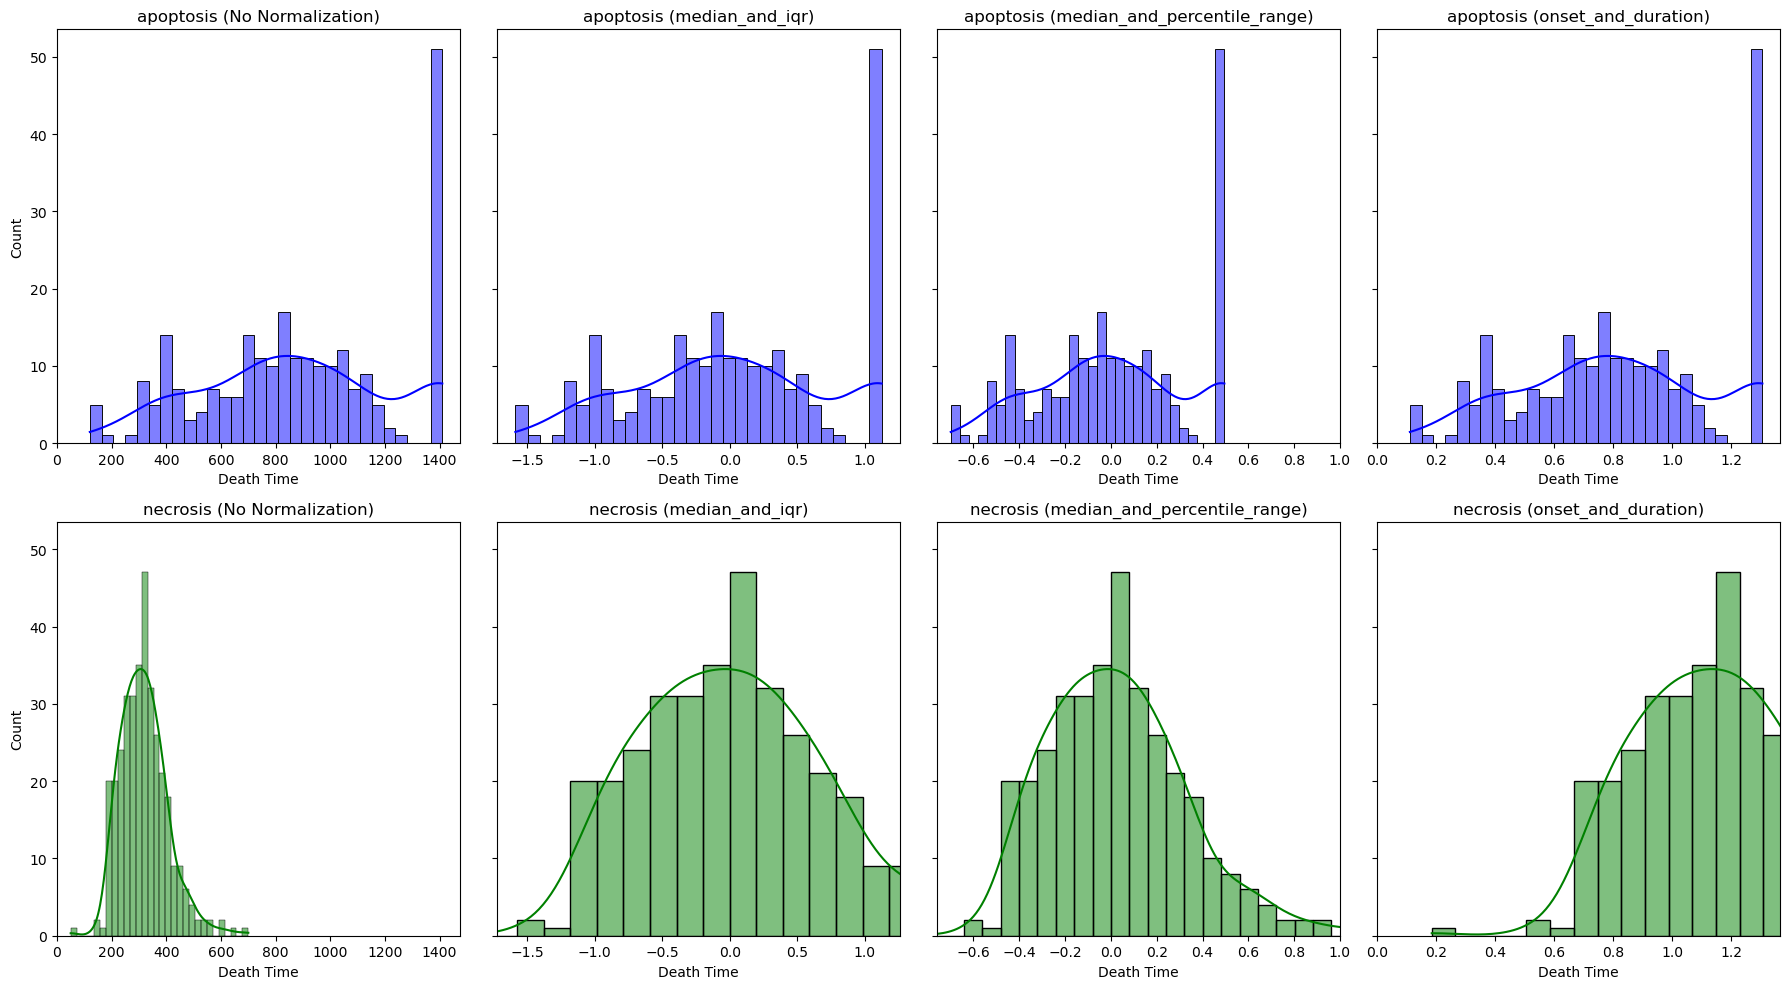

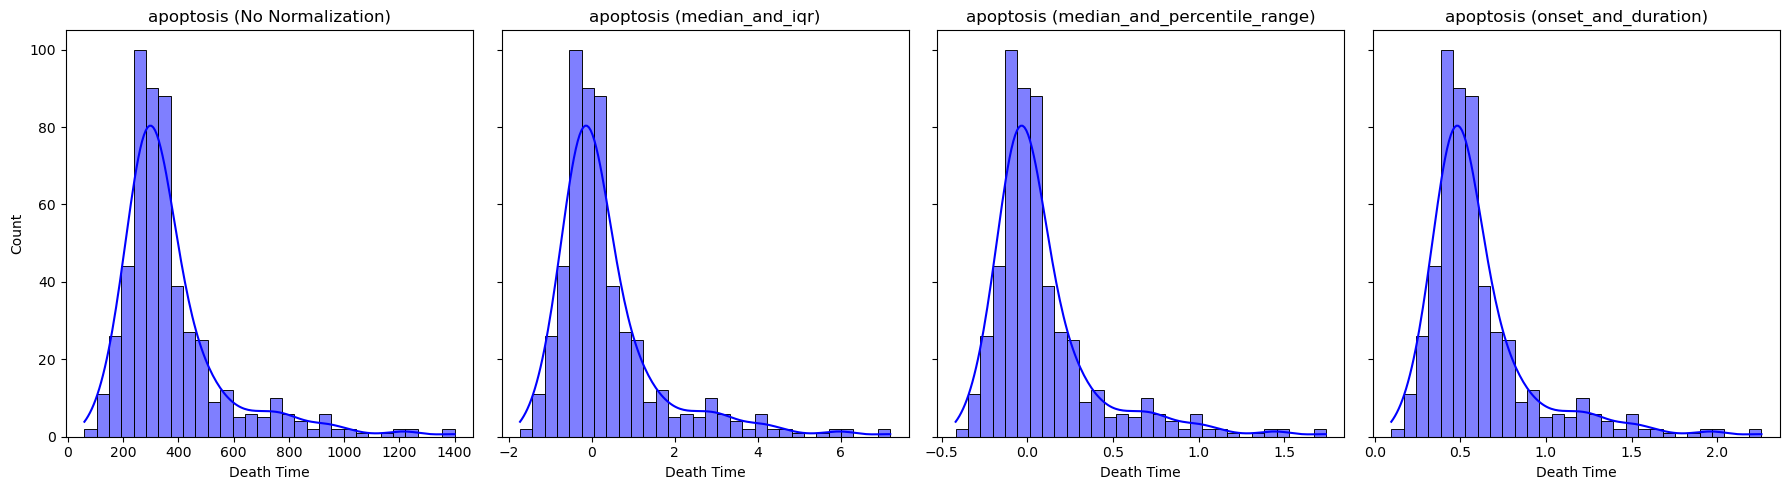

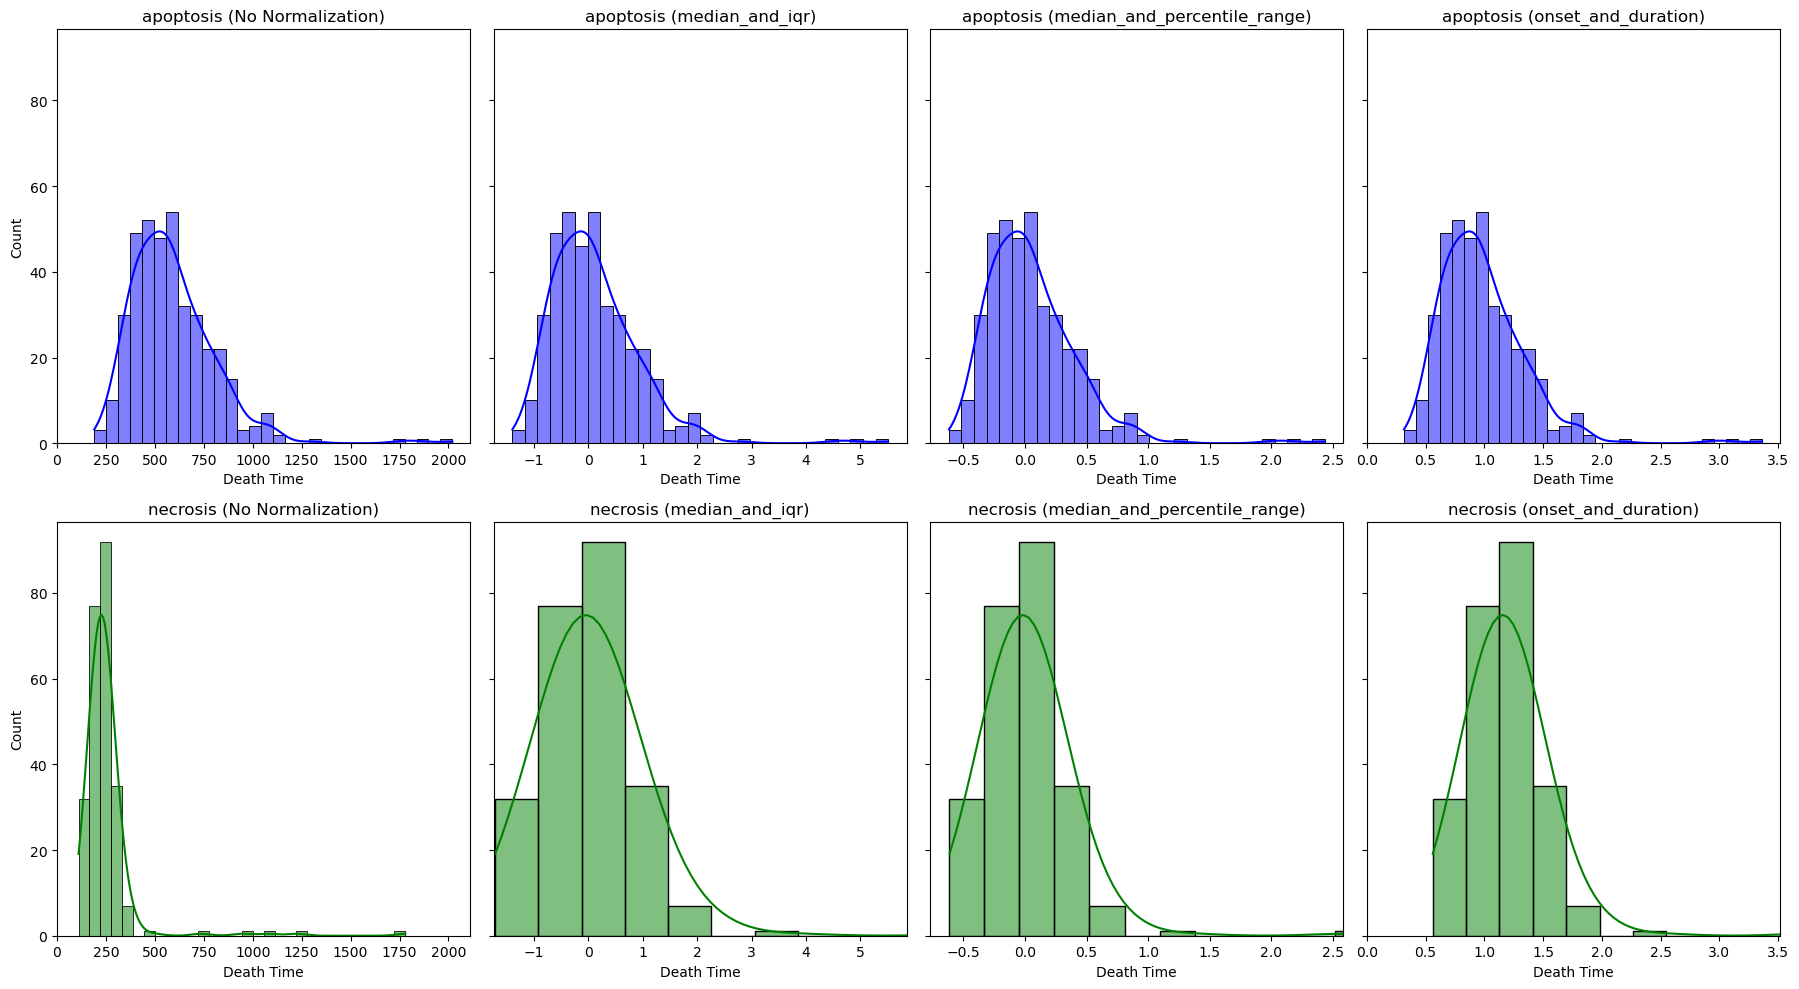

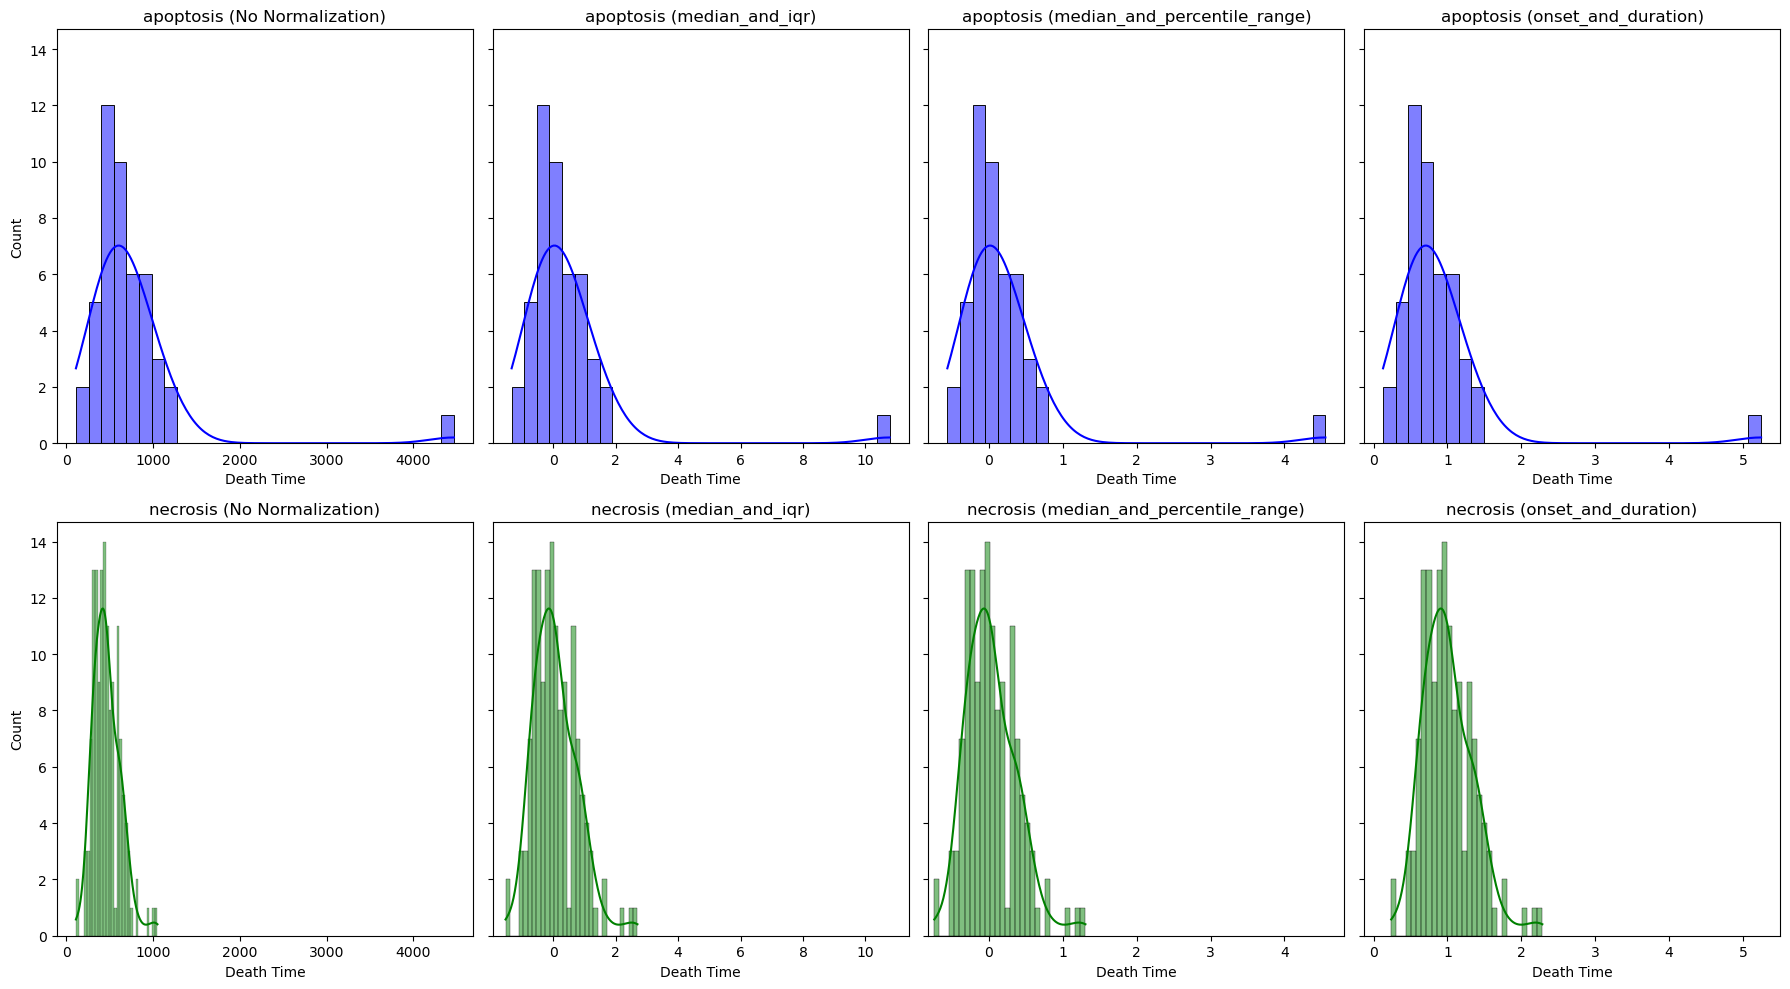

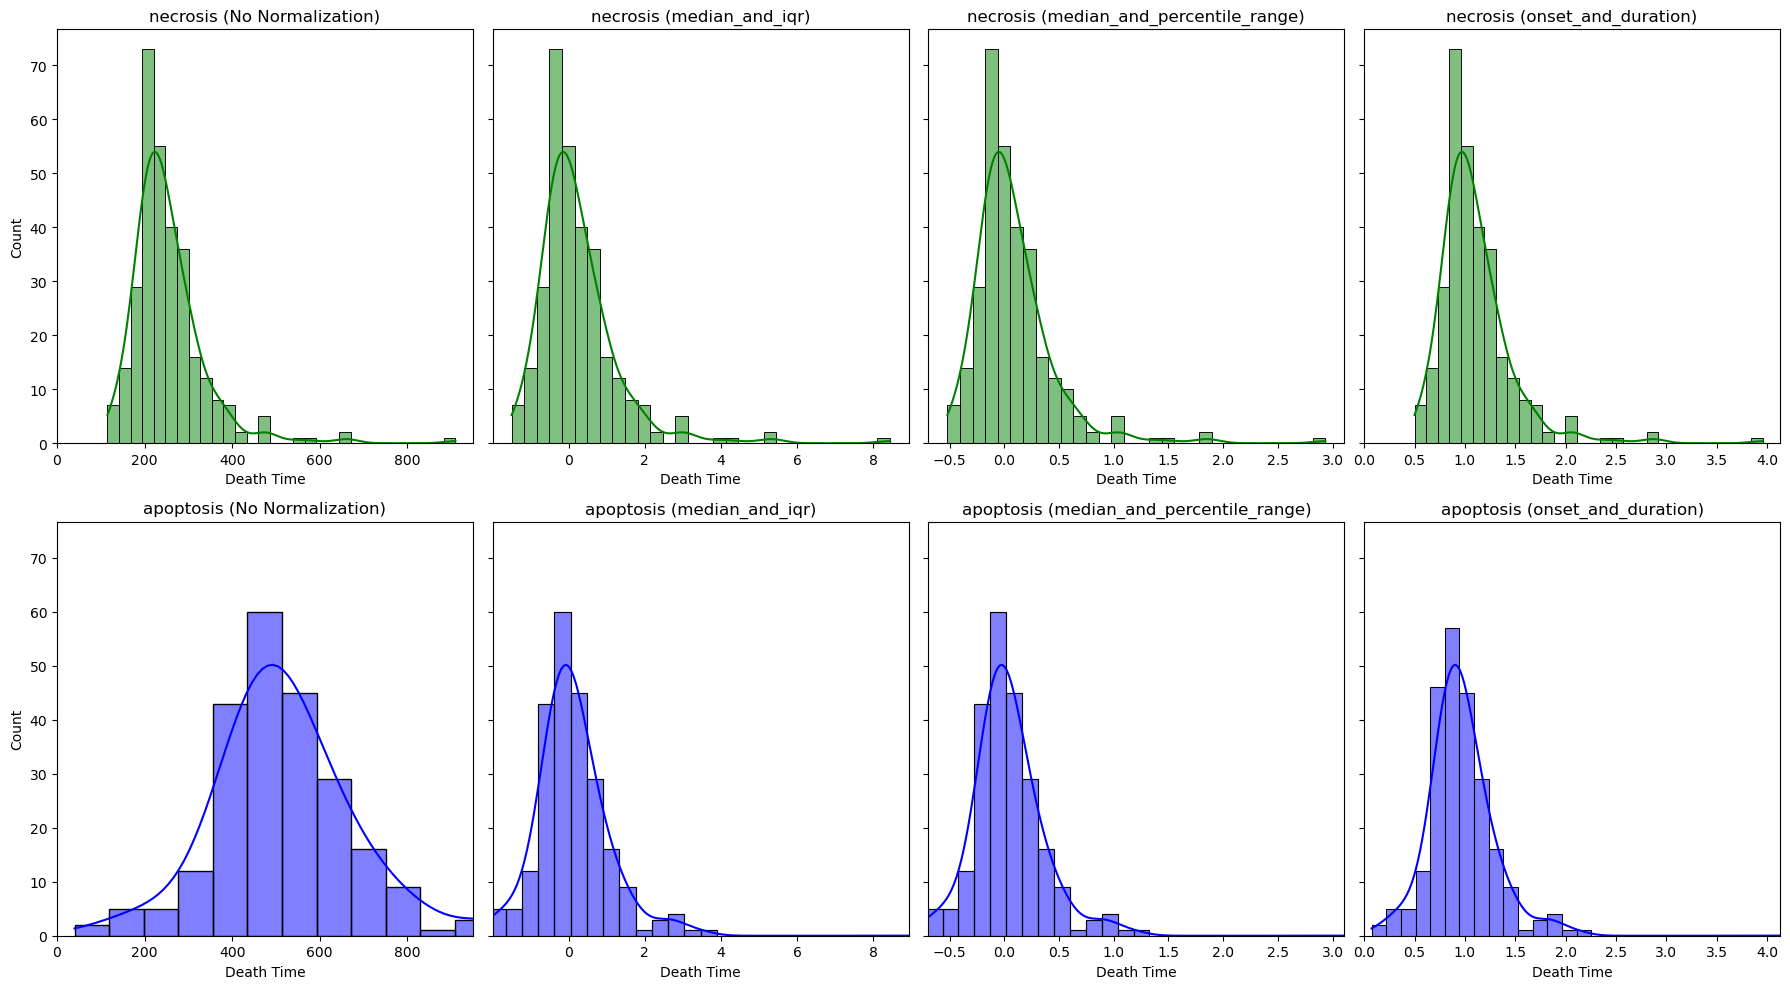

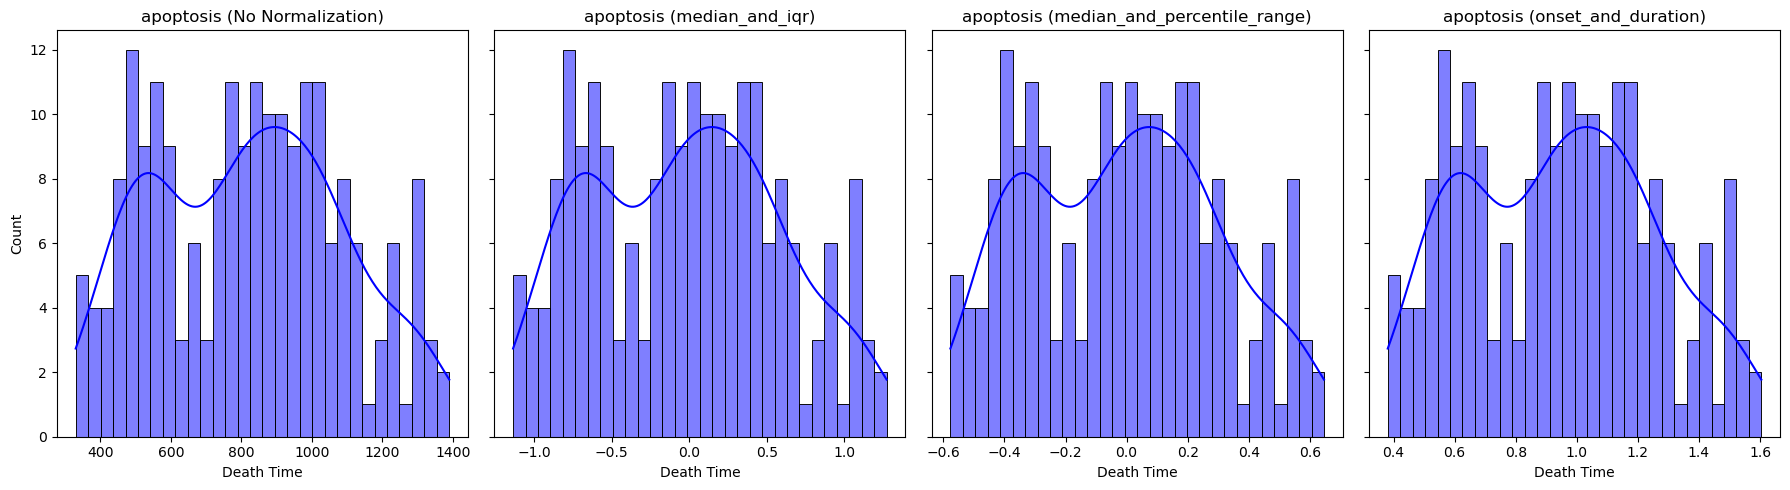

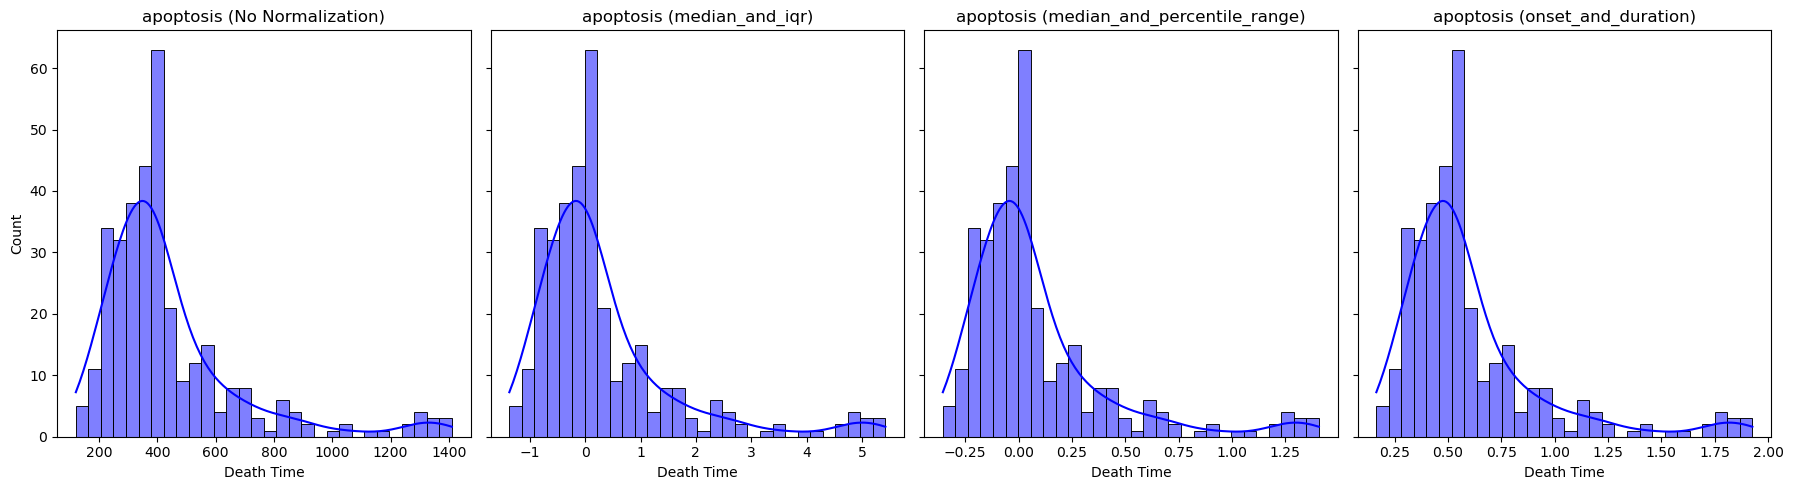

In [2]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') and 'mix' in file.lower():  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Check if there is more than one mode in the file
        if death_modes is None:
            df["Mode"] = ["necrosis" if "nec" in file or 'pure' in file else "apoptosis"]* len(death_times)
        unique_modes = df['Mode'].unique()
        unique_modes = [mode for mode in unique_modes if mode in ["necrosis", "apoptosis"]]
        fig, axes = plt.subplots(len(unique_modes), 4, figsize=(18, 5 * len(unique_modes)), sharey=True)
        for i, mode in enumerate(unique_modes):
        # Filter data by mode
            subset = df[df['Mode'] == mode]
            cells_location_subset = subset[["cell_x", "cell_y"]].values
            death_times_subset = subset['death_time'].values
            death_modes_subset = subset["Mode"].values if "Mode" in subset.columns else None

            normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration']

            for j, n_type in enumerate(normalization_types):
                # Apply DeathQuanta with different normalization types
                de_qu = DeathQuanta(
                cells_xy=cells_location_subset,
                death_times=death_times_subset,
                death_modes=death_modes_subset,
                dist_threshold=dist_threshold,
                normalize=True if n_type else False,
                n_type=n_type if n_type else None,
                filter_neighbors_by_distance=True,
                neighbors_level=1,
                )

                # Get normalized death times
                normalized_death_times = de_qu.death_times.copy()

                # Plot the distribution.
                if len(unique_modes) > 1:
                    sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[i, j], color='blue' if mode == 'apoptosis' else 'green')
                    axes[i, j].set_title(f'{mode} ({n_type if n_type else "No Normalization"})')
                    # Set uniform x-axis limits for each column
                    x_min = min(ax.get_xlim()[0] for ax in axes[:, j])
                    x_max = max(ax.get_xlim()[1] for ax in axes[:, j])
                    for ax in axes[:, j]:
                        ax.set_xlim(x_min, x_max)
                    axes[i, j].set_xlabel('Death Time')
                else:
                    sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[j], color='blue' if mode == 'apoptosis' else 'green')
                    axes[ j].set_title(f'{mode} ({n_type if n_type else "No Normalization"})')
                    # Set uniform x-axis limits for each column
                    x_min = min(ax.get_xlim()for ax in axes)
                    x_max = max(ax.get_xlim() for ax in axes)

                    axes[j].set_xlabel('Death Time')

        plt.tight_layout()
        plt.show()
            # break  # Remove this line if you want to process all files
        



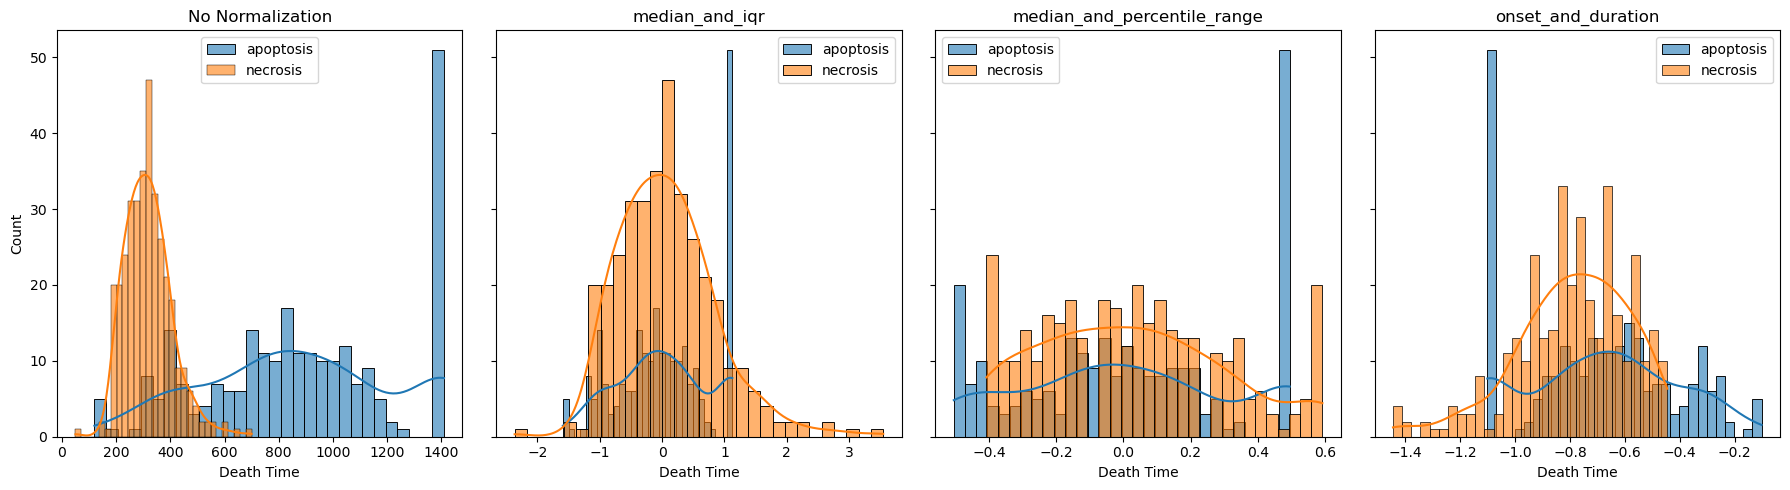

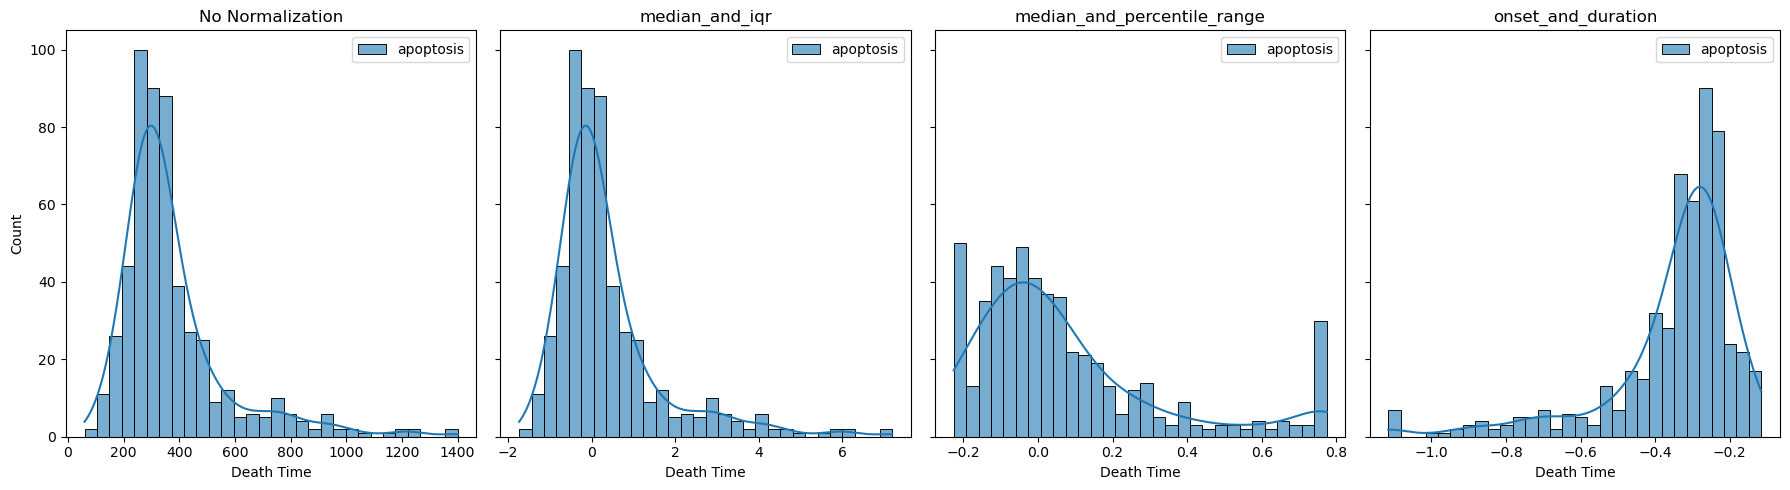

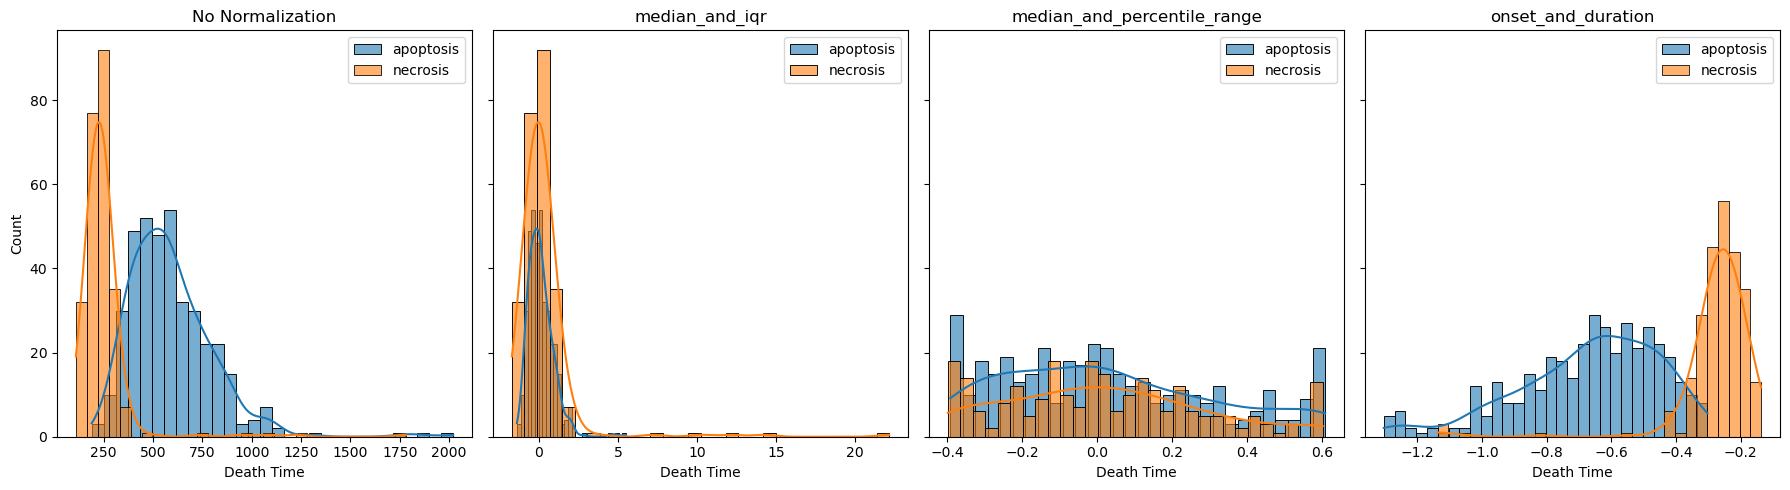

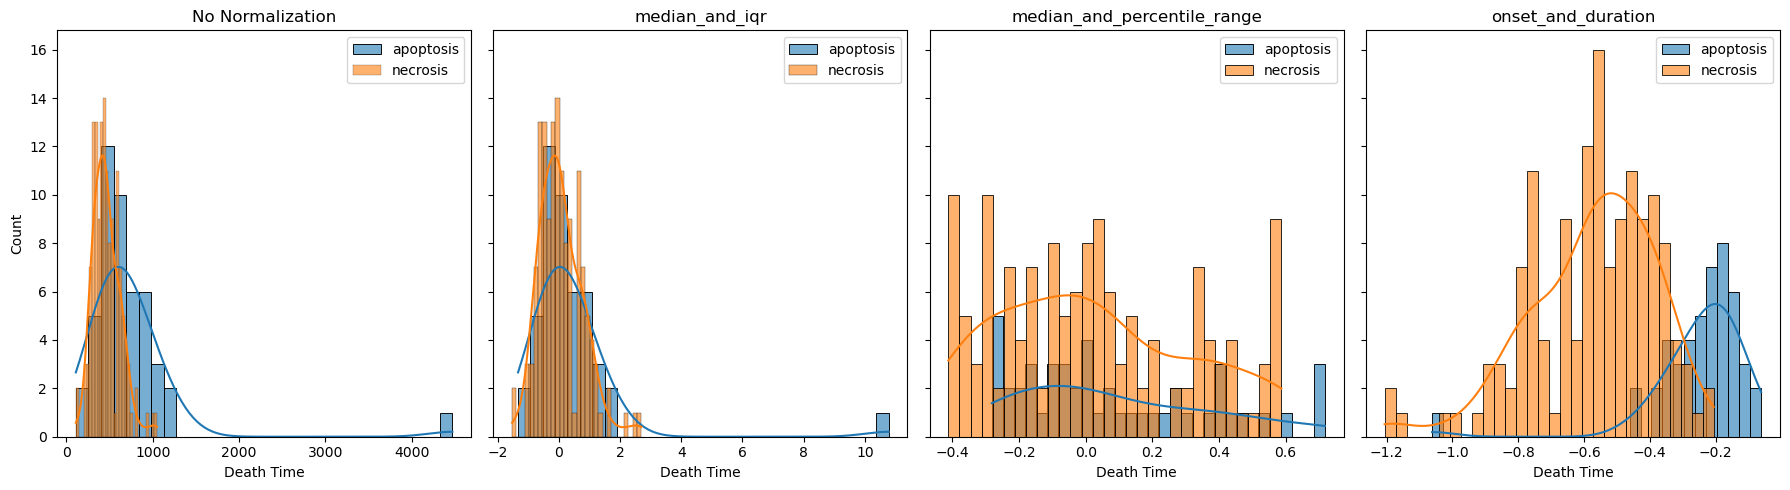

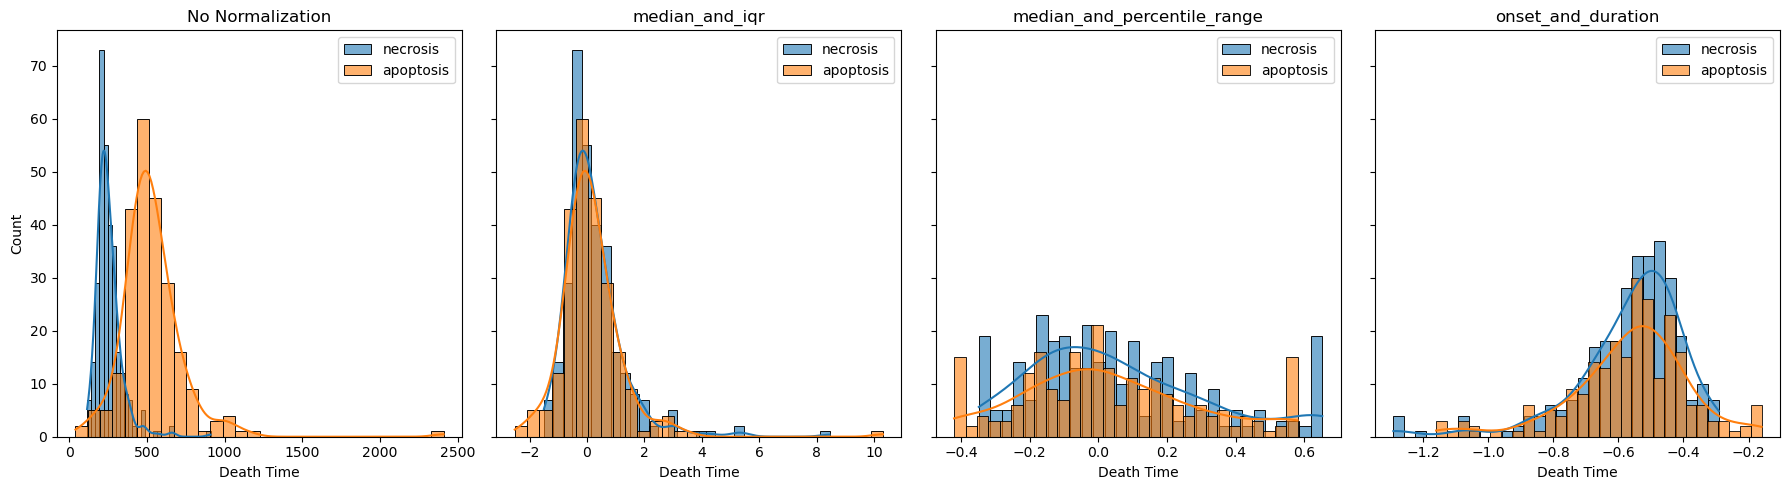

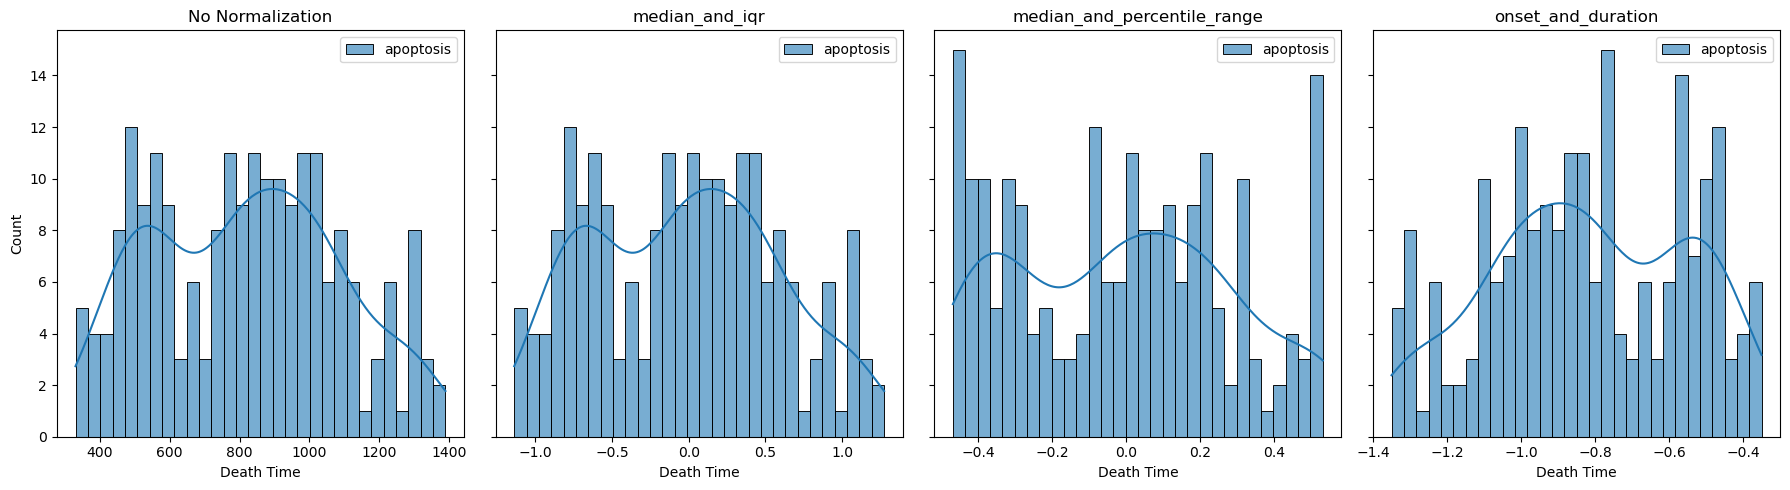

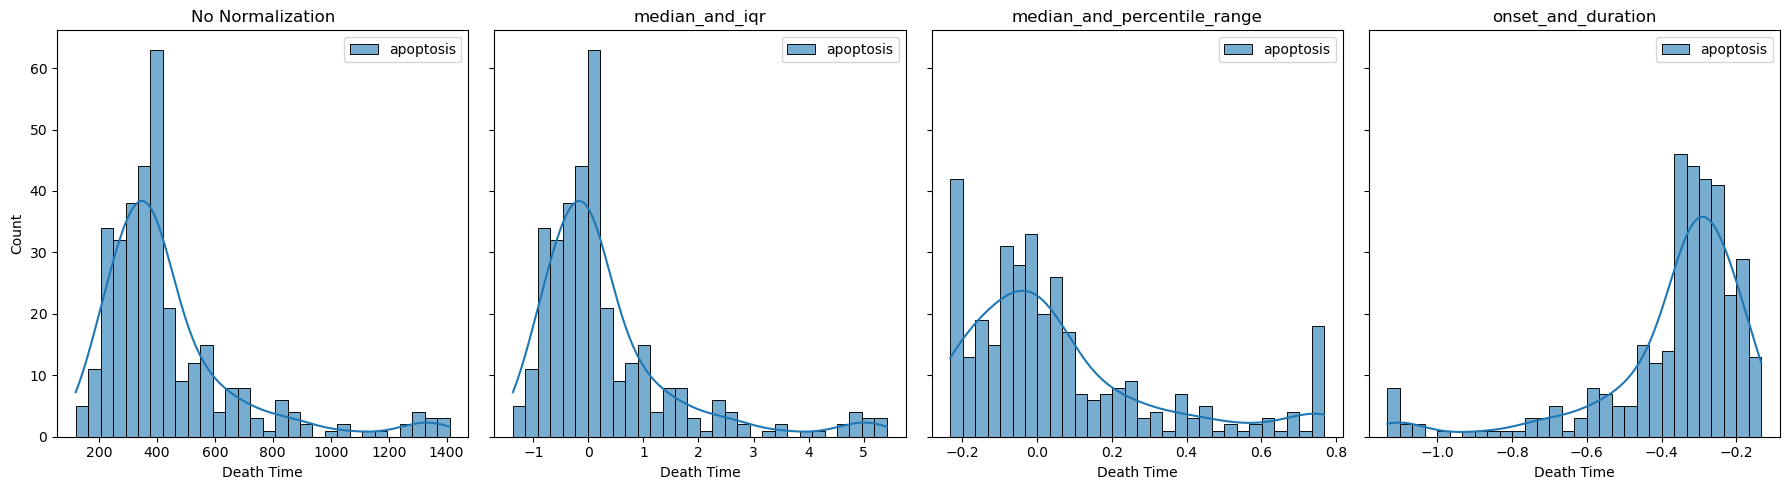

In [2]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv'):  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Check if there is more than one mode in the file
        if death_modes is None:
            df["Mode"] = ["necrosis" if "nec" in file or 'pure' in file else "apoptosis"] * len(death_times)
        unique_modes = df['Mode'].unique()
        unique_modes = [mode for mode in unique_modes if mode in ["necrosis", "apoptosis"]]
        
        normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration']
        
        if 'mix' in file.lower():
            fig, axes = plt.subplots(1, len(normalization_types), figsize=(18, 5), sharey=True)
            for j, n_type in enumerate(normalization_types):
                for mode in unique_modes:
                    # Filter data by mode
                    subset = df[df['Mode'] == mode]
                    cells_location_subset = subset[["cell_x", "cell_y"]].values
                    death_times_subset = subset['death_time'].values
                    death_modes_subset = subset["Mode"].values if "Mode" in subset.columns else None

                    # Apply DeathQuanta with different normalization types
                    de_qu = DeathQuanta(
                        cells_xy=cells_location_subset,
                        death_times=death_times_subset,
                        death_modes=death_modes_subset,
                        dist_threshold=dist_threshold,
                        normalize=True if n_type else False,
                        n_type=n_type if n_type else None,
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                    )

                    # Get normalized death times
                    normalized_death_times = de_qu.death_times.copy()

                    # Plot the distribution
                    sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[j], label=mode, alpha=0.6)
                    axes[j].set_title(f'{n_type if n_type else "No Normalization"}')
                    axes[j].set_xlabel('Death Time')
                axes[j].legend()
            plt.tight_layout()
            plt.show()
        else:
            continue


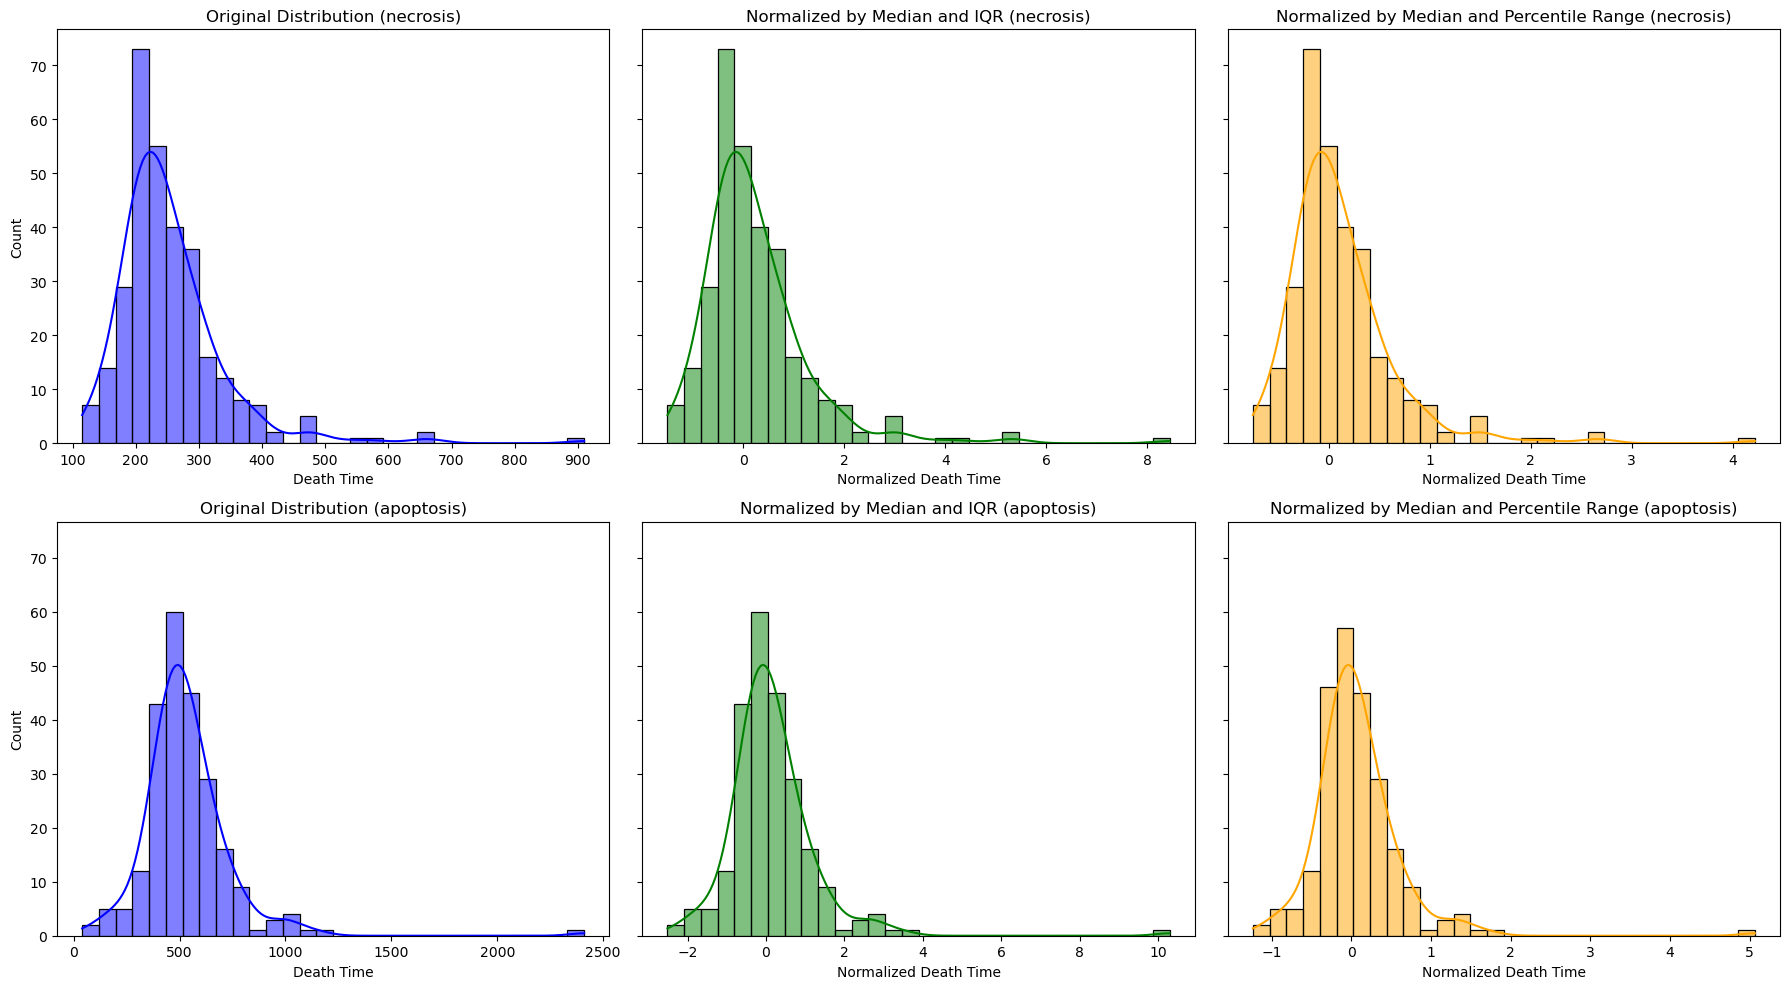

In [5]:
# Get unique modes
modes = df_csv['Mode'].unique()

# Create subplots
fig, axes = plt.subplots(len(modes), 3, figsize=(18, 5 * len(modes)), sharey=True)

for i, mode in enumerate(modes):
    # Filter data by mode
    subset = df_csv[df_csv['Mode'] == mode]
    death_times_subset = subset['death_time'].values

    # Normalize the subset
    normalized_iqr_subset = normalize_by_median_and_iqr([death_times_subset])[0]
    normalized_percentile_range_subset = normalize_by_median_and_percentile_range([death_times_subset])[0]

    # Plot original distribution
    sns.histplot(death_times_subset, bins=30, kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Original Distribution ({mode})')
    axes[i, 0].set_xlabel('Death Time')

    # Plot normalized by IQR
    sns.histplot(normalized_iqr_subset, bins=30, kde=True, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'Normalized by Median and IQR ({mode})')
    axes[i, 1].set_xlabel('Normalized Death Time')

    # Plot normalized by Percentile Range
    sns.histplot(normalized_percentile_range_subset, bins=30, kde=True, ax=axes[i, 2], color='orange')
    axes[i, 2].set_title(f'Normalized by Median and Percentile Range ({mode})')
    axes[i, 2].set_xlabel('Normalized Death Time')

plt.tight_layout()
plt.show()

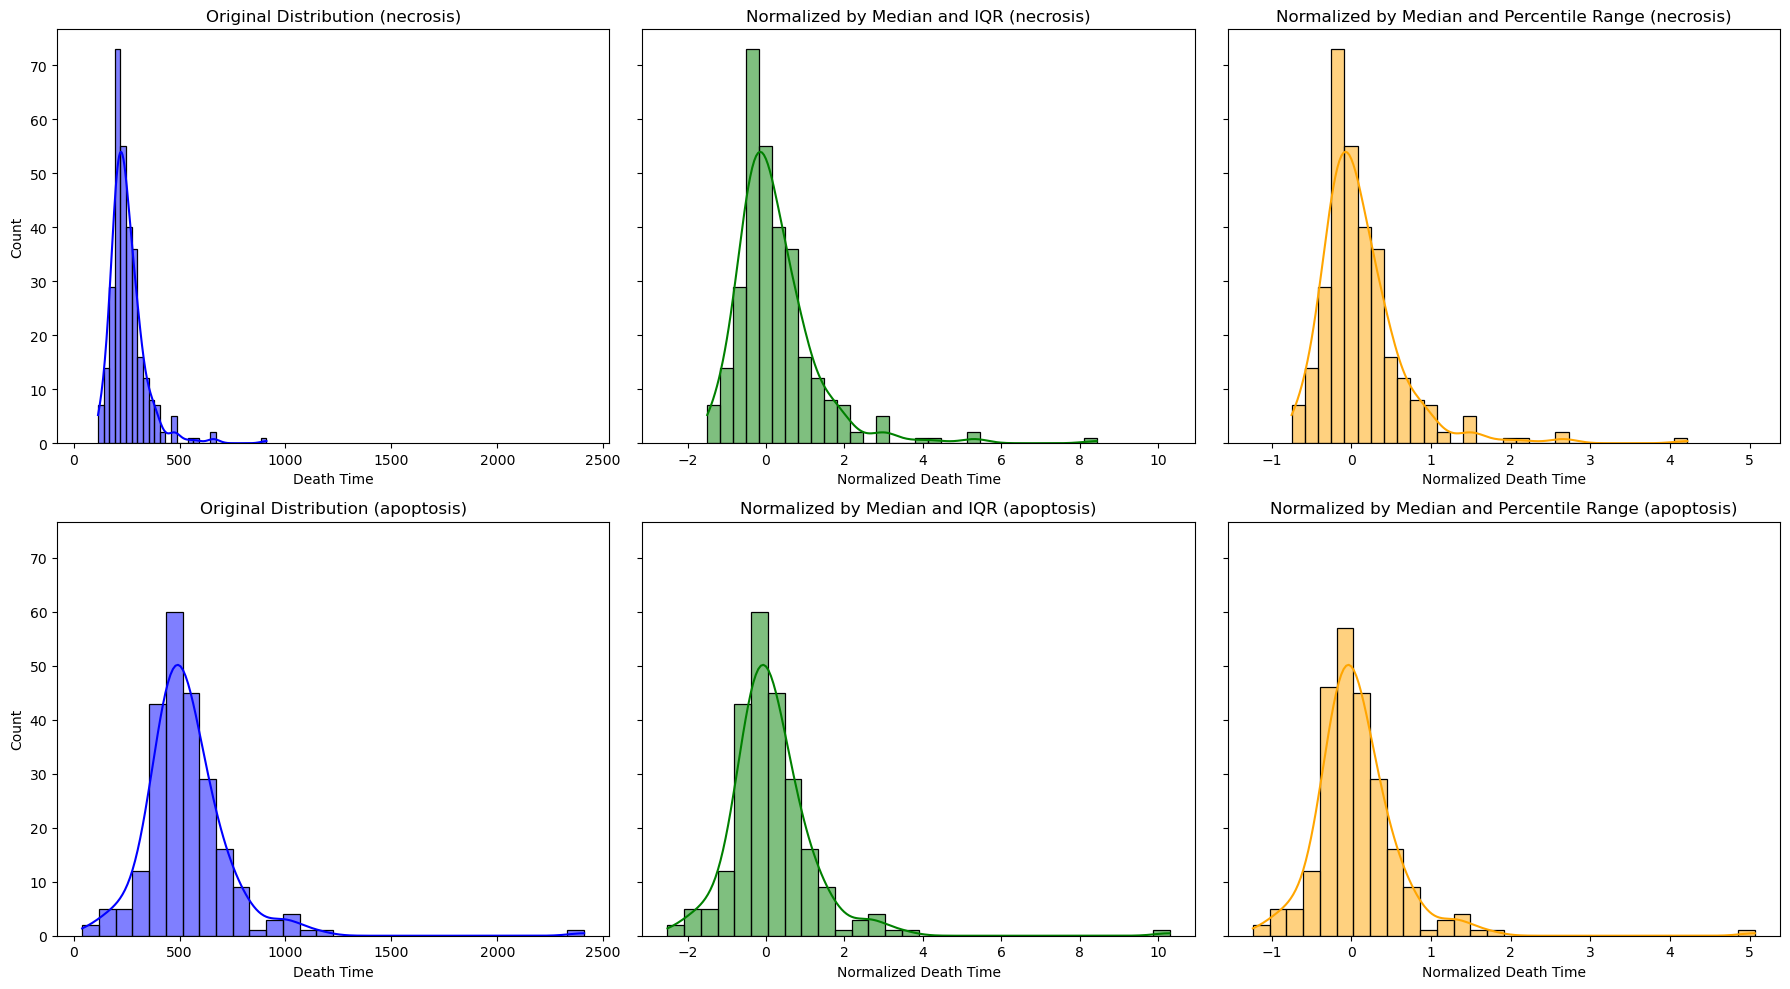

In [6]:
# Get unique modes
modes = df_csv['Mode'].unique()

# Create subplots
fig, axes = plt.subplots(len(modes), 3, figsize=(18, 5 * len(modes)), sharey=True)

for i, mode in enumerate(modes):
    # Filter data by mode
    subset = df_csv[df_csv['Mode'] == mode]
    death_times_subset = subset['death_time'].values

    # Normalize the subset
    normalized_iqr_subset = normalize_by_median_and_iqr([death_times_subset])[0]
    normalized_percentile_range_subset = normalize_by_median_and_percentile_range([death_times_subset])[0]

    # Plot original distribution
    sns.histplot(death_times_subset, bins=30, kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Original Distribution ({mode})')
    axes[i, 0].set_xlabel('Death Time')

    # Plot normalized by IQR
    sns.histplot(normalized_iqr_subset, bins=30, kde=True, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'Normalized by Median and IQR ({mode})')
    axes[i, 1].set_xlabel('Normalized Death Time')

    # Plot normalized by Percentile Range
    sns.histplot(normalized_percentile_range_subset, bins=30, kde=True, ax=axes[i, 2], color='orange')
    axes[i, 2].set_title(f'Normalized by Median and Percentile Range ({mode})')
    axes[i, 2].set_xlabel('Normalized Death Time')

plt.tight_layout()
# Set uniform x-axis limits for all subplots
for j in range(3):  # Iterate over the columns
    x_min = min(ax.get_xlim()[0] for ax in axes[:, j])
    x_max = max(ax.get_xlim()[1] for ax in axes[:, j])
    for ax in axes[:, j]:
        ax.set_xlim(x_min, x_max)

plt.show()

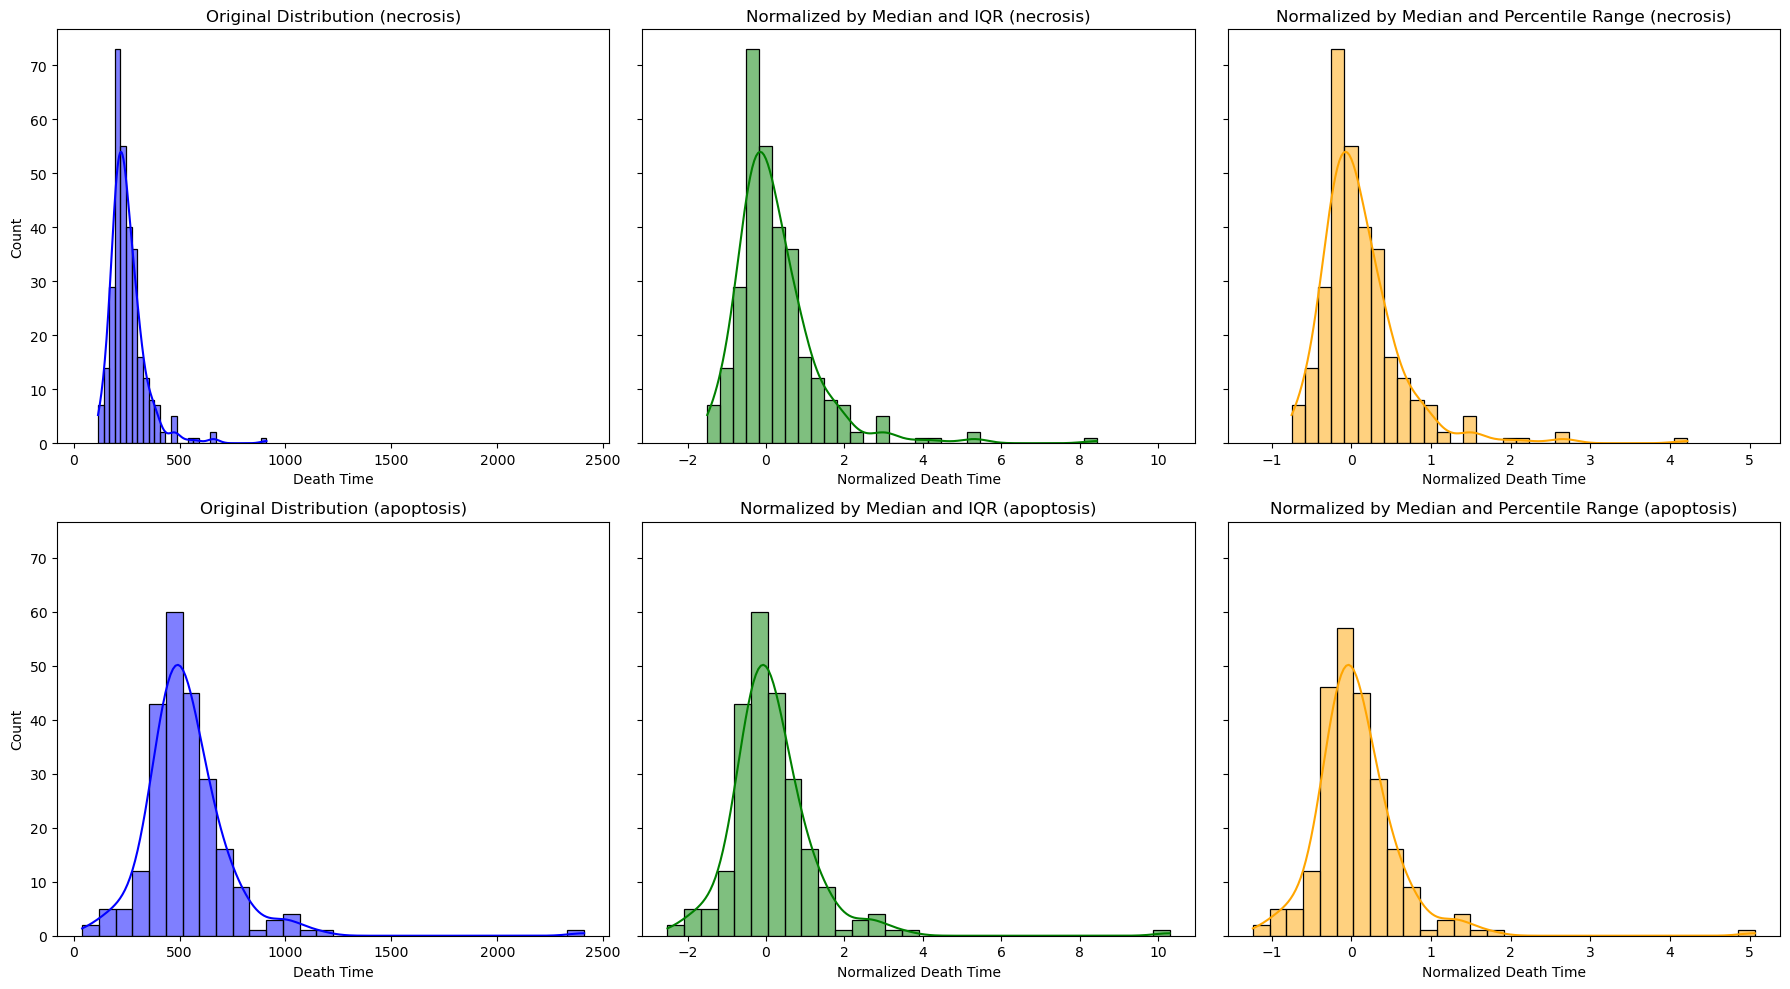

In [7]:
# Get unique modes
modes = df_csv['Mode'].unique()

# Create subplots
fig, axes = plt.subplots(len(modes), 3, figsize=(18, 5 * len(modes)), sharey=True)

for i, mode in enumerate(modes):
    # Filter data by mode
    subset = df_csv[df_csv['Mode'] == mode]
    death_times_subset = subset['death_time'].values

    # Normalize the subset
    normalized_iqr_subset = normalize_by_median_and_iqr([death_times_subset])[0]
    normalized_percentile_range_subset = normalize_by_median_and_percentile_range([death_times_subset])[0]

    # Plot original distribution
    sns.histplot(death_times_subset, bins=30, kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Original Distribution ({mode})')
    axes[i, 0].set_xlabel('Death Time')

    # Plot normalized by IQR
    sns.histplot(normalized_iqr_subset, bins=30, kde=True, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'Normalized by Median and IQR ({mode})')
    axes[i, 1].set_xlabel('Normalized Death Time')

    # Plot normalized by Percentile Range
    sns.histplot(normalized_percentile_range_subset, bins=30, kde=True, ax=axes[i, 2], color='orange')
    axes[i, 2].set_title(f'Normalized by Median and Percentile Range ({mode})')
    axes[i, 2].set_xlabel('Normalized Death Time')

plt.tight_layout()
# Set uniform x-axis limits for all subplots
for j in range(3):  # Iterate over the columns
    x_min = min(ax.get_xlim()[0] for ax in axes[:, j])
    x_max = max(ax.get_xlim()[1] for ax in axes[:, j])
    for ax in axes[:, j]:
        ax.set_xlim(x_min, x_max)

plt.show()

In [13]:
normalize_by_median_and_iqr([death_times_subset])

[array([-1.94594595,  0.59459459,  0.62162162, -0.05405405,  0.37837838,
        -1.75675676,  1.21621622,  0.86486486,  0.48648649,  0.37837838,
         0.89189189,  1.40540541, -0.43243243,  0.78378378,  0.94594595,
        -0.62162162, -0.62162162,  0.32432432, -0.72972973, -0.59459459,
         0.64864865,  0.05405405,  0.16216216,  0.18918919,  0.35135135,
         0.10810811,  1.7027027 , -0.32432432, -1.02702703, -1.40540541,
        -1.40540541, -0.51351351, -0.45945946,  1.2972973 ,  0.67567568,
        -1.86486486, -0.24324324, -0.51351351, -0.51351351, -0.43243243,
        -0.18918919, -0.67567568, -0.62162162,  0.08108108, -0.62162162,
        -0.02702703,  2.89189189, -0.43243243, -0.18918919,  1.45945946,
         0.43243243,  0.37837838, -0.02702703,  0.        ,  0.32432432,
         0.86486486, -0.54054054, -0.56756757,  0.10810811, -0.24324324,
        -0.18918919, -1.16216216, -0.86486486,  0.48648649,  0.10810811,
        -0.78378378,  0.21621622,  0.27027027,  0.5

/tmp/ipykernel_3802891/3097993763.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(normalized_distributions, labels=file_names, vert=False)


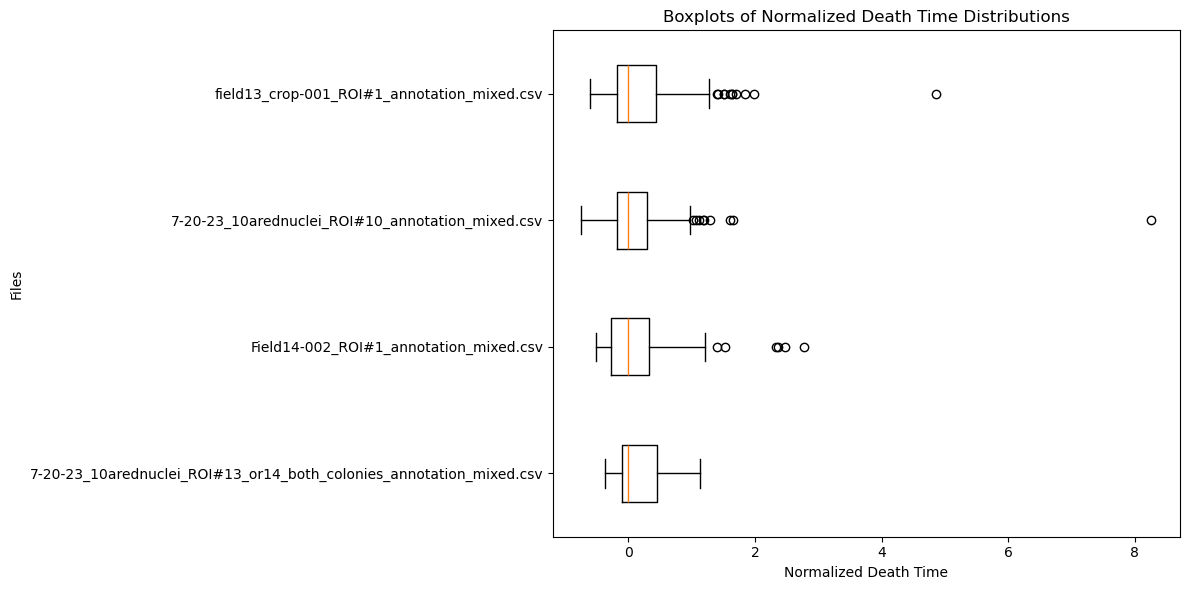

In [8]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# List to store normalized distributions
normalized_distributions = []
file_names = []

# Iterate over files in the directory
for file in os.listdir(dir_files):
    if 'mixed' in file and file.endswith('.csv'):
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Apply normalization
        death_times = df['death_time'].values
        normalized = normalize_by_median_and_percentile_range([death_times])[0]
        
        # Store the normalized distribution and file name
        normalized_distributions.append(normalized)
        file_names.append(file)

# Plot boxplots
plt.figure(figsize=(12, 6))
plt.boxplot(normalized_distributions, labels=file_names, vert=False)
plt.title('Boxplots of Normalized Death Time Distributions')
plt.xlabel('Normalized Death Time')
plt.ylabel('Files')
plt.tight_layout()
plt.show()

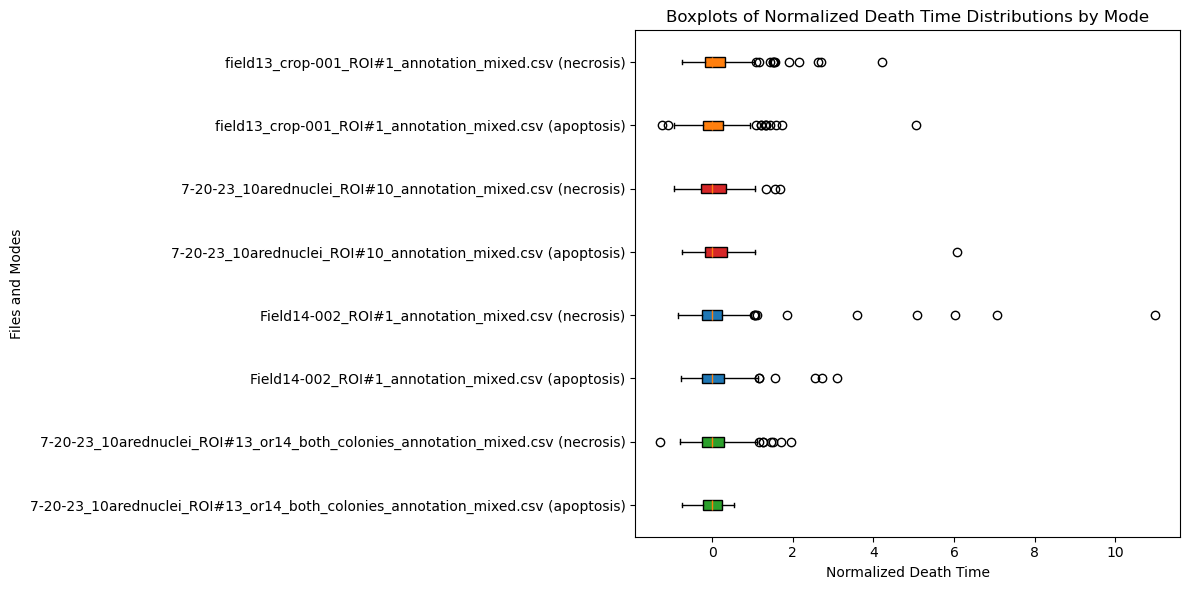

In [9]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store normalized distributions by file and mode
normalized_distributions_by_mode = {}

# Iterate over files in the directory
for file in os.listdir(dir_files):
    if 'mixed' in file and file.endswith('.csv'):
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Group by mode
        for mode, subset in df.groupby('Mode'):
            if mode not in ["apoptosis", "necrosis"]:
                continue
            death_times = subset['death_time'].values
            normalized = normalize_by_median_and_percentile_range([death_times])[0]
            
            # Store the normalized distribution
            if (file, mode) not in normalized_distributions_by_mode:
                normalized_distributions_by_mode[(file, mode)] = []
            normalized_distributions_by_mode[(file, mode)].append(normalized)

# Assign unique colors to each file
files = list(set(file for file, _ in normalized_distributions_by_mode.keys()))
file_colors = {file: plt.cm.tab10(i % 10) for i, file in enumerate(files)}

# Plot boxplots for each mode in each file
plt.figure(figsize=(12, 6))

# Assign unique positions on the x-axis for each boxplot
positions = range(len(normalized_distributions_by_mode))
labels = [f"{file} ({mode})" for (file, mode) in normalized_distributions_by_mode.keys()]

# Plot the boxplots
for pos, ((file, mode), distributions) in zip(positions, normalized_distributions_by_mode.items()):
    plt.boxplot(distributions, positions=[pos], vert=False, patch_artist=True,
                boxprops=dict(facecolor=file_colors[file]))

# Set the x-axis labels
plt.yticks(positions, labels)
plt.title('Boxplots of Normalized Death Time Distributions by Mode')
plt.xlabel('Normalized Death Time')
plt.ylabel('Files and Modes')
plt.tight_layout()
plt.show()

In [19]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    # if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    if 'mixed' not in exp_names[idx]:
        continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    # Filter data by death mode
    death_modes_unique = csv_file['Mode'].unique()
    cells_location = []
    di_times = []
    death_modes = []
    
    for mode in death_modes_unique:
        mode_subset = csv_file[csv_file['Mode'] == mode]
        cells_location.extend(mode_subset[["cell_x", "cell_y"]].values)
        normalized_times = normalize_by_median_and_percentile_range([mode_subset['death_time'].values])[0]
        di_times.extend(normalized_times)
        death_modes.extend(mode_subset["Mode"].values)

    # Convert lists to numpy arrays
    cells_location = np.array(cells_location)
    di_times = np.array(di_times)
    cells_location = csv_file[["cell_x","cell_y"]].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Error sorting death times: zero-dimensional arrays cannot be concatenated
Field14-002_ROI#1_annotation_mixed.csv
Error sorting death times: zero-dimensional arrays cannot be concatenated
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
Error sorting death times: zero-dimensional arrays cannot be concatenated
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
Error sorting death times: zero-dimensional arrays cannot be concatenated


In [15]:
di_times

array([ 0.46875   ,  0.375     ,  0.46875   ,  0.28125   ,  0.25      ,
        0.21875   ,  0.28125   ,  0.        ,  0.09375   ,  0.15625   ,
        0.03125   ,  0.        , -0.03125   , -0.0625    ,  0.15625   ,
       -0.0625    , -0.03125   ,  0.        , -0.25      , -0.1875    ,
       -0.03125   ,  0.        , -0.09375   , -0.1875    , -0.28125   ,
        0.09375   , -0.34375   ,  0.09375   , -0.15625   ,  0.        ,
       -0.09375   , -0.1875    , -0.34375   , -0.75      , -0.21875   ,
       -0.21875   , -0.25      , -0.3125    , -0.34375   , -0.5       ,
       -0.5625    , -0.65625   , -0.65625   , -0.5625    , -0.5625    ,
       -0.5625    , -0.03125   ,  0.        , -0.375     ,  0.        ,
       -0.09375   ,  0.3125    ,  0.21875   ,  0.46875   ,  0.46875   ,
       -0.1875    , -0.28125   , -0.4375    , -0.25      ,  0.15625   ,
        0.15625   ,  0.4375    ,  0.6875    ,  0.46875   ,  0.65625   ,
        0.90625   ,  0.53125   ,  0.125     ,  0.0625    , -0.68

In [25]:

# Flatten the nested dictionary into a list of records
records = []
for major_group, subgroups in group_data.items():
    for minor_group, values in subgroups.items():
        for value in values:
            records.append({'MajorGroup': major_group, 'MinorGroup': minor_group, 'TOD': value})

# Create a DataFrame from the records
df = pd.DataFrame(records)

# Display the DataFrame
print(df)

              MajorGroup MinorGroup       TOD
0         field13_colony  apoptosis  1.875000
1         field13_colony  apoptosis  1.821809
2         field13_colony  apoptosis  0.132979
3         field13_colony  apoptosis  1.648936
4         field13_colony  apoptosis  1.143617
...                  ...        ...       ...
9275  field14_two_colony   necrosis  1.650000
9276  field14_two_colony   necrosis  0.700000
9277  field14_two_colony   necrosis  1.500000
9278  field14_two_colony   necrosis  1.200000
9279  field14_two_colony   necrosis  0.900000

[9280 rows x 3 columns]


/tmp/ipykernel_3802891/1984831561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MinorGroup', y='TOD', data=df, width=0.5, palette='pastel', showfliers=False)


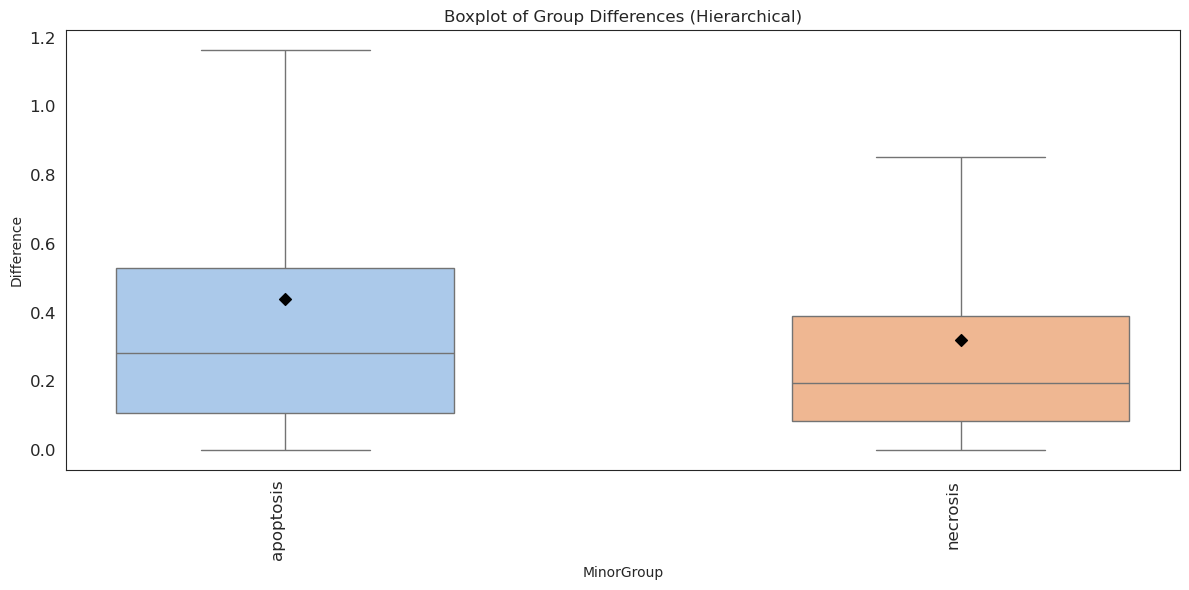

In [26]:
# Add a temporary column for sorting
df['SortOrder'] = df['MajorGroup'].apply(lambda x: 1 if 'pure' in x.lower() else 0)

# Sort the DataFrame by the temporary column and GroupLabel
df = df.sort_values(by=['SortOrder', 'MinorGroup'], ascending=[True, True])

# Drop the temporary column used for sorting
df = df.drop(columns=['SortOrder'])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")
sns.boxplot(x='MinorGroup', y='TOD', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['MinorGroup'].unique()):
    values = df[df['MinorGroup'] == label]['TOD']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(df['MinorGroup'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical_sorted.svg", format="svg", dpi=300)
plt.show()


/tmp/ipykernel_3802891/2795134160.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filtered_df = pd.concat([filtered_df, filtered_group])
/tmp/ipykernel_3802891/2795134160.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MinorGroup', y='TOD', data=filtered_df, width=0.5, palette='pastel', showfliers=False)


<Figure size 1200x600 with 0 Axes>

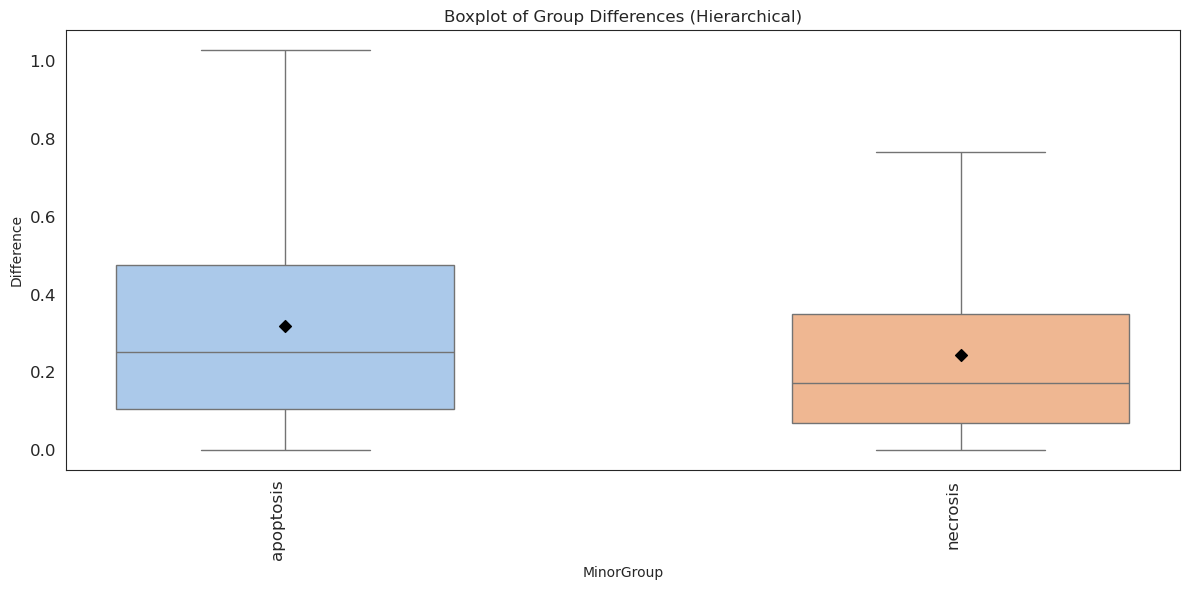

In [ ]:
# Add a temporary column for sorting
df['SortOrder'] = df['MajorGroup'].apply(lambda x: 1 if 'pure' in x.lower() else 0)

# Sort the DataFrame by the temporary column and MinorGroup
df = df.sort_values(by=['SortOrder', 'MinorGroup'], ascending=[True, True])

# Drop the temporary column used for sorting
df = df.drop(columns=['SortOrder'])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")

# Remove outliers for each group and subgroup
filtered_df = pd.DataFrame(columns=df.columns)
for group_label in df['MinorGroup'].unique():
    group_values = df[df['MinorGroup'] == group_label]['TOD']
    lower_bound = np.percentile(group_values, 5)
    upper_bound = np.percentile(group_values, 95)
    filtered_group = df[(df['MinorGroup'] == group_label) & (df['TOD'] >= lower_bound) & (df['TOD'] <= upper_bound)]
    filtered_df = pd.concat([filtered_df, filtered_group])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='MinorGroup', y='TOD', data=filtered_df, width=0.5, palette='pastel', showfliers=False)

# Annotate mean
for i, label in enumerate(filtered_df['MinorGroup'].unique()):
    values = filtered_df[filtered_df['MinorGroup'] == label]['TOD']
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)
    # plt.text(i, mean, f'{mean:.2f}', va='center', ha='right', fontsize=9, color='green')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(filtered_df['MinorGroup'].unique())))
plt.yticks(fontsize=12)
# sns.boxplot(x='GroupLabel', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['MinorGroup'].unique()):
    values = df[df['MinorGroup'] == label]['TOD']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(df['MinorGroup'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_new_hierarchical_sorted_no_out.svg", format="svg", dpi=300)
plt.show()


/tmp/ipykernel_3802891/603099179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='TOD', data=df, width=0.5, palette='pastel', showfliers=False)


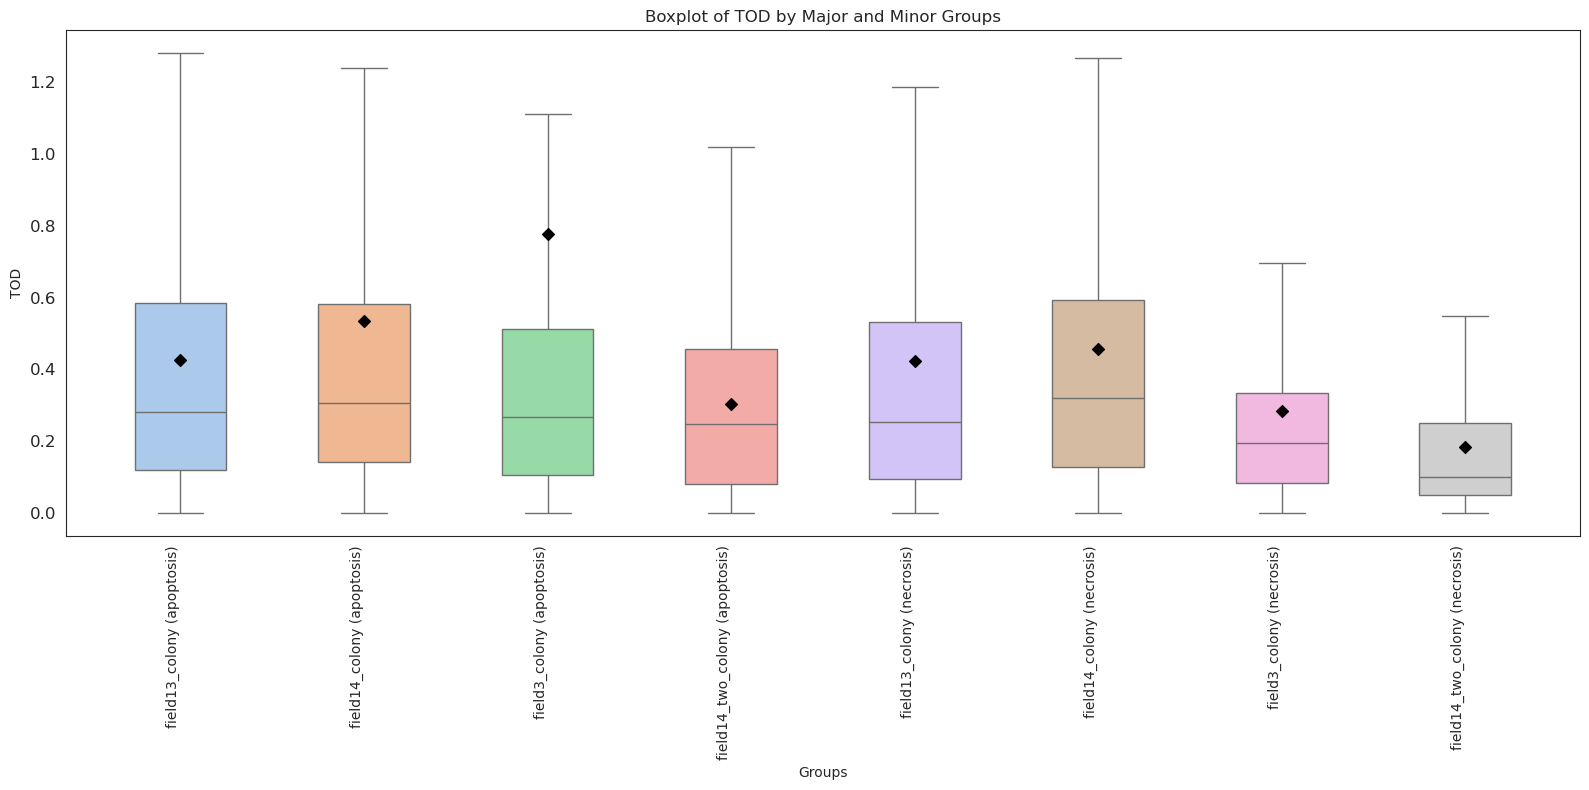

In [31]:
# Create a new column combining MajorGroup and MinorGroup for plotting
df['Group'] = df['MajorGroup'] + " (" + df['MinorGroup'] + ")"

# Plot boxplot
plt.figure(figsize=(16, 8))
sns.set_style("white")
sns.boxplot(x='Group', y='TOD', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate mean for each group
for i, label in enumerate(df['Group'].unique()):
    values = df[df['Group'] == label]['TOD']
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)

plt.xticks(fontsize=10, rotation=90, ha='right', ticks=range(len(df['Group'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of TOD by Major and Minor Groups')
plt.ylabel('TOD')
plt.xlabel('Groups')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_major_minor_groups.svg", format="svg", dpi=300)
plt.show()


# Normalization of TODs

In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

## OLD data

In [3]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/OriginalTimeMinutesData/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/ExperimentsMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    if "compressed" in exp_names[idx] or "compressed" in exp_names[idx].lower():
        continue
    try: 
        print(exp_names[idx])
        exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
        csv_file = pd.read_csv(exp_full_path)
        dist_threshold = 100 # microns
        cells_location = csv_file[["cell_x","cell_y"]].values
        di_times = csv_file[['death_time']].values
        death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
        name = replace_ugly_long_name(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Treatment"].values[0],
                            meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Cell Line"].values[0])
        de_qu = DeathQuanta(cells_xy=cells_location,
                            death_times=di_times, 
                            death_modes=death_modes,
                            dist_threshold=dist_threshold,
                            filter_neighbors_by_distance=True,
                            neighbors_level=1,
                            pure_type = name)
        tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
        if name not in group_data:
            group_data[name] = {}
        group_data[name][exp_names[idx]]= tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1
    except Exception as e:
        continue

20160820_10A_FB_xy11.csv
20160820_10A_FB_xy12.csv
20160820_10A_FB_xy13.csv
20160820_10A_FB_xy14.csv
20160820_10A_FB_xy15.csv
20160828_10AsgCx43_FB_xy01.csv
20160828_10AsgCx43_FB_xy02.csv
20160828_10AsgCx43_FB_xy03.csv
20160828_10AsgCx43_FB_xy04.csv
20160828_10AsgCx43_FB_xy05.csv
20160828_10AsgCx43_FB_xy06.csv
20160828_10AsgCx43_FB_xy07.csv
20160828_10AsgCx43_FB_xy08.csv
20160828_10AsgCx43_FB_xy09.csv
20160828_10AsgCx43_FB_xy10.csv
20160828_10AsgCx43_FB_xy11.csv
20160828_10AsgCx43_FB_xy13.csv
20160828_10Awt_FB_xy01.csv
20160828_10Awt_FB_xy02.csv
20160828_10Awt_FB_xy03.csv
20160828_10Awt_FB_xy04.csv
20160828_10Awt_FB_xy05.csv
20160909_b16f10_aMSH_xy36.csv
20160909_b16f10_aMSH_xy37.csv
20160909_b16f10_aMSH_xy38.csv
20160909_b16f10_aMSH_xy39.csv
20160909_b16f10_aMSH_xy40.csv
20161129_MCF7_FB_xy11.csv
20161129_MCF7_FB_xy12.csv
20161129_MCF7_FB_xy13.csv
20161129_MCF7_FB_xy14.csv
20161129_MCF7_FB_xy15.csv
20170213_U937_FB_xy1.csv
20170213_U937_FB_xy2.csv
20170213_U937_FB_xy3.csv
20170213_U937

/tmp/ipykernel_743080/449565903.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


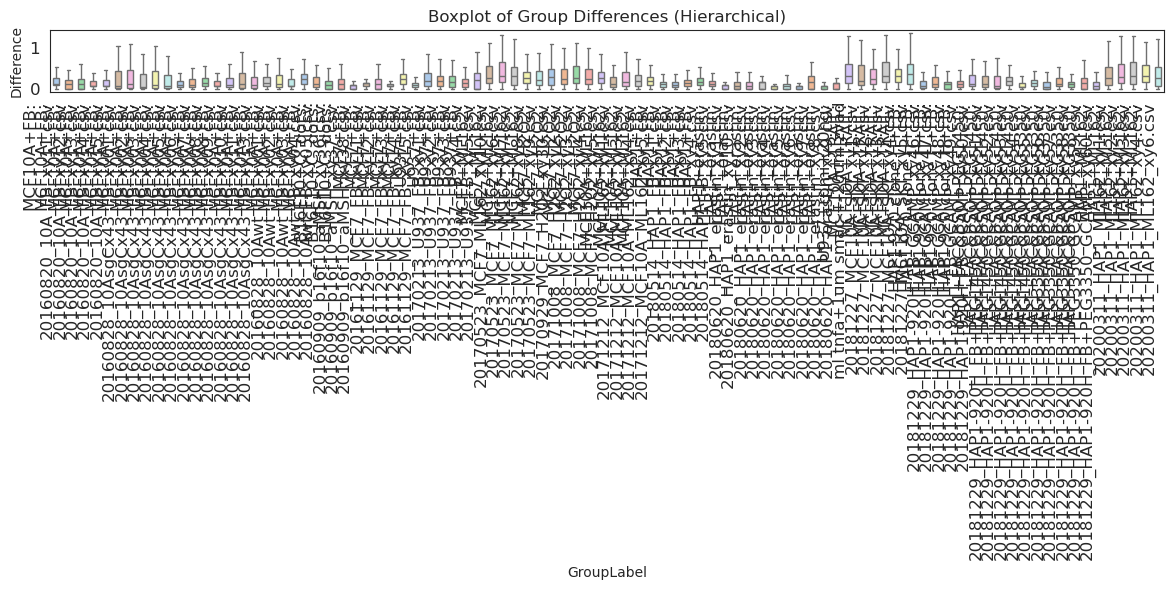

In [5]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



/tmp/ipykernel_743080/496661313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
/tmp/ipykernel_743080/496661313.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')


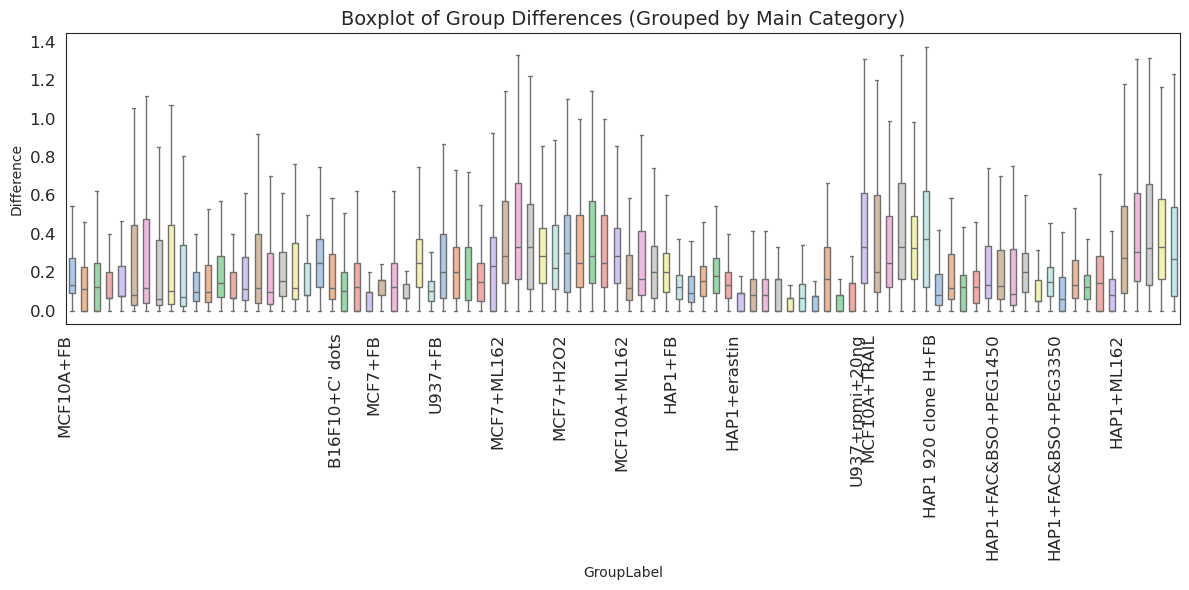

In [6]:
# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
                 width=0.5, palette='pastel', showfliers=False)

# Replace subgroup labels with main group labels only once per group
group_labels = df['GroupLabel'].unique()
main_groups = [label.split(':\n')[0] for label in group_labels]

# Build condensed label list where each main group appears only at first index
x_labels = []
seen = set()
for g in main_groups:
    if g not in seen:
        x_labels.append(g)
        seen.add(g)
    else:
        x_labels.append("")

# Apply the new tick labels
ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')

# Continue formatting
plt.yticks(fontsize=12)
plt.title('Boxplot of Group Differences (Grouped by Main Category)', fontsize=14)
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()


## Recent Data

In [2]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        # n_type = 'median_and_iqr',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Field14-002_ROI#1_annotation_mixed.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
purecolony3.csv
purecolony1.csv
Purecolony2.csv
mixcolony1.csv
mixcolony2_field13.csv
mixcolony3.csv


In [3]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        # n_type = 'median_and_iqr',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Field14-002_ROI#1_annotation_mixed.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
purecolony3_sytox_based.csv
purecolony_sytox_based.csv
purecolony2_sytox_based.csv
mixcolony1.csv
mixcolony2_field13.csv
mixcolony3.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath3_sytox_based.csv


/tmp/ipykernel_781433/672842238.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


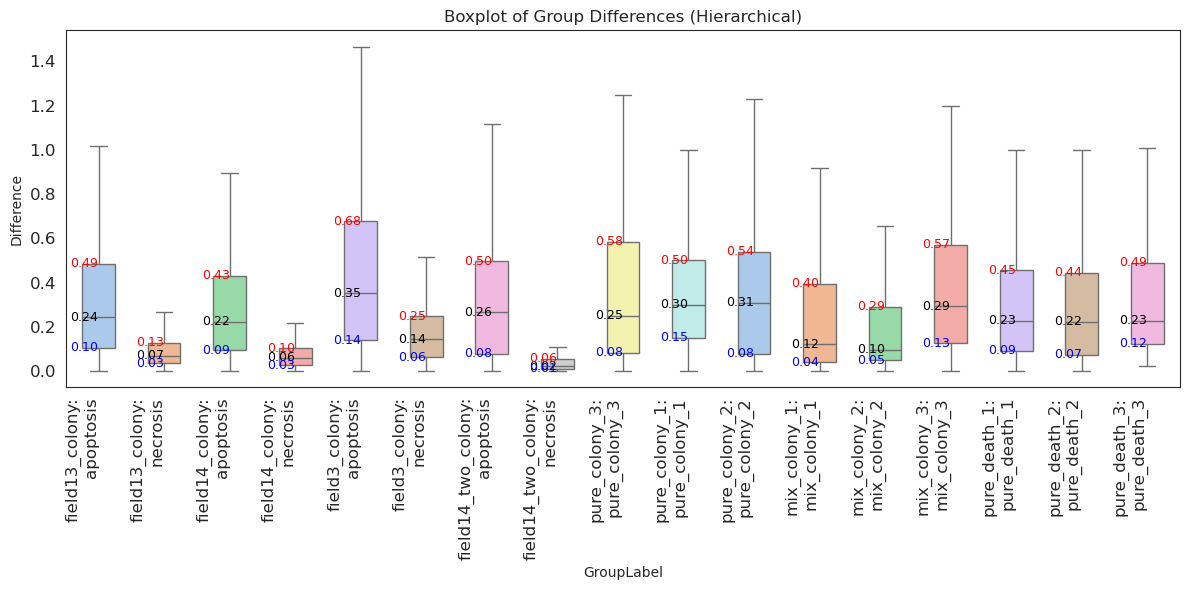

In [25]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



In [20]:
filtered_df = df.copy()

In [22]:
# Filter out groups with "mixed" in their Group or MainGroup
filtered_df = df[~df['Group'].str.contains('mix', case=False) & ~df['MainGroup'].str.contains('field3', case=False )]#& ~df['MainGroup'].str.contains('pure_colony_1', case=False)]

# Display the filtered DataFrame
print(filtered_df)

                          Group  Difference       MainGroup      SubGroup  \
0      field13_colony/apoptosis    0.867052  field13_colony     apoptosis   
1      field13_colony/apoptosis    0.867052  field13_colony     apoptosis   
2      field13_colony/apoptosis    2.323699  field13_colony     apoptosis   
3      field13_colony/apoptosis    1.976879  field13_colony     apoptosis   
4      field13_colony/apoptosis    0.554913  field13_colony     apoptosis   
...                         ...         ...             ...           ...   
40765              pure_death_3    0.864198    pure_death_3  pure_death_3   
40766              pure_death_3    0.864198    pure_death_3  pure_death_3   
40767              pure_death_3    0.843621    pure_death_3  pure_death_3   
40768              pure_death_3    0.493827    pure_death_3  pure_death_3   
40769              pure_death_3    0.843621    pure_death_3  pure_death_3   

                        GroupLabel  
0       field13_colony:\napoptosis  
1

/tmp/ipykernel_772436/672842238.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


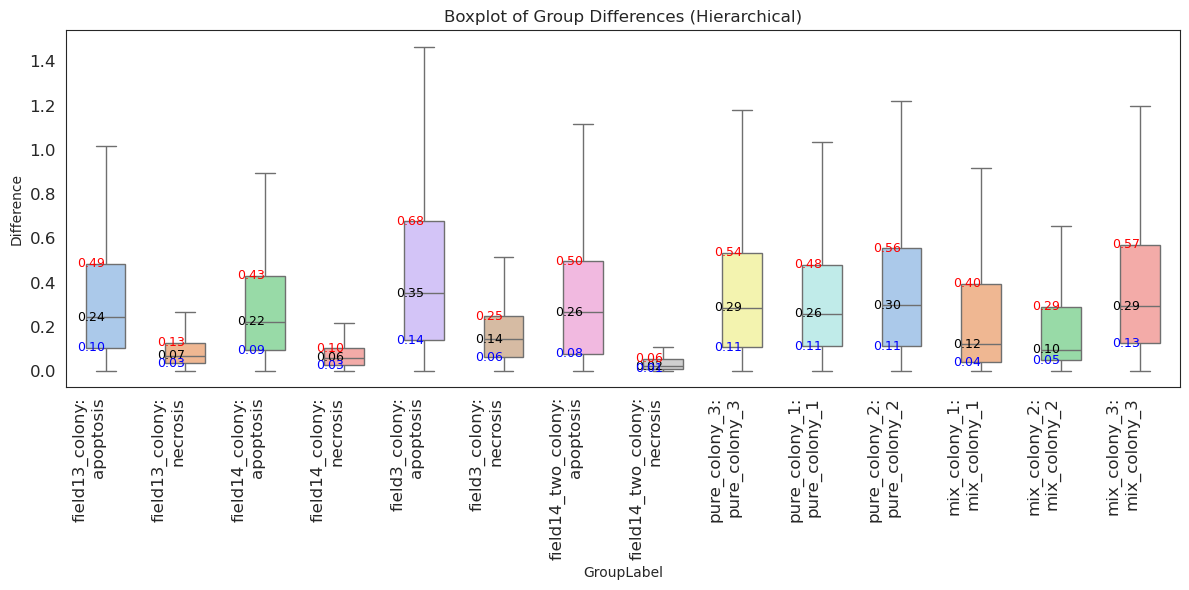

In [30]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



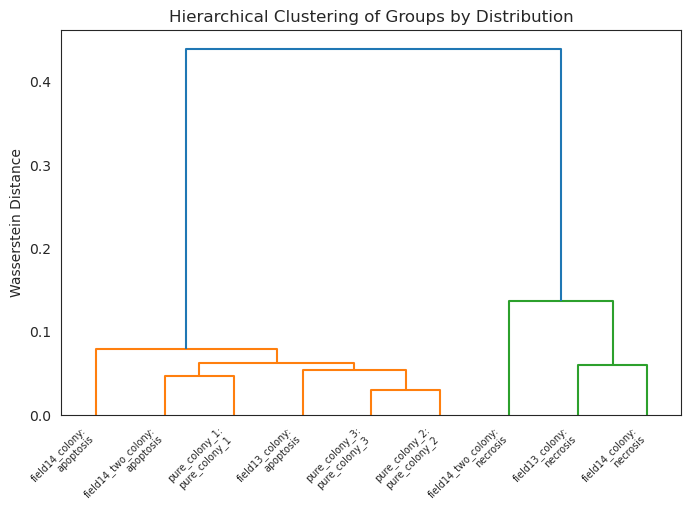

In [ ]:
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Example input: dict of group_name -> list of values
# 1. Compute pairwise Wasserstein distances
group_names = filtered_df['GroupLabel'].unique()
n = len(group_names)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        group_i_values = filtered_df[filtered_df['GroupLabel'] == group_names[i]]['Difference'].values
        group_j_values = filtered_df[filtered_df['GroupLabel'] == group_names[j]]['Difference'].values
        dist = stats.energy_distance(group_i_values, group_j_values)
        dist_matrix[i, j] = dist_matrix[j, i] = dist

# 2. Hierarchical clustering
linkage_matrix = linkage(squareform(dist_matrix), method='average')
# 3. Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=group_names)
plt.title('Hierarchical Clustering of Groups by Distribution')
plt.ylabel('Wasserstein Distance')
# Set x-axis labels horizontally
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def extract_features(values):
    return [
        np.mean(values),
        np.std(values),
        stats.skew(values),
        stats.kurtosis(values),
        np.percentile(values, 10),
        np.percentile(values, 50),
        np.percentile(values, 90),
    ]

# Group by 'GroupLabel' and extract features
grouped = filtered_df.groupby('GroupLabel')['Difference']
feature_matrix = np.array([extract_features(values) for _, values in grouped])
group_names = grouped.groups.keys()

# Scale the features
scaled_features = StandardScaler().fit_transform(feature_matrix)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(scaled_features)

# Print the cluster assignments
for name, label in zip(group_names, labels):
    print(f"{name}: Cluster {label}")


field13_colony:
apoptosis: Cluster 0
field13_colony:
necrosis: Cluster 1
field14_colony:
apoptosis: Cluster 0
field14_colony:
necrosis: Cluster 1
field14_two_colony:
apoptosis: Cluster 0
field14_two_colony:
necrosis: Cluster 1
pure_colony_1:
pure_colony_1: Cluster 0
pure_colony_2:
pure_colony_2: Cluster 0
pure_colony_3:
pure_colony_3: Cluster 0
pure_death_1:
pure_death_1: Cluster 0
pure_death_2:
pure_death_2: Cluster 0
pure_death_3:
pure_death_3: Cluster 0


In [11]:
from scipy.stats import wasserstein_distance, energy_distance

def compute_distance_matrix(filtered_df, method='energy'):
    group_names = filtered_df['GroupLabel'].unique()
    n = len(group_names)
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = filtered_df[filtered_df['GroupLabel'] == group_names[i]]['Difference'].values
            group_j_values = filtered_df[filtered_df['GroupLabel'] == group_names[j]]['Difference'].values
            if method == 'wasserstein':
                d = wasserstein_distance(group_i_values, group_j_values)
            elif method == 'energy':
                d = energy_distance(group_i_values, group_j_values)
            dist_matrix[i, j] = dist_matrix[j, i] = d
    return dist_matrix, group_names


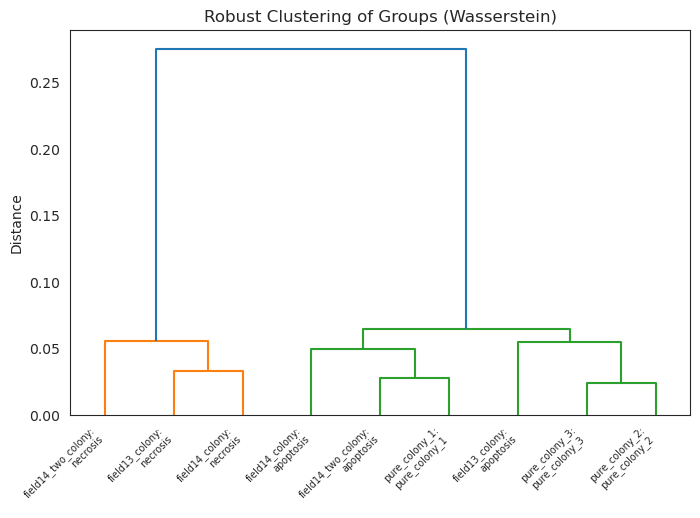

field13_colony:
apoptosis: Cluster 4
field13_colony:
necrosis: Cluster 1
field14_colony:
apoptosis: Cluster 3
field14_colony:
necrosis: Cluster 1
field14_two_colony:
apoptosis: Cluster 3
field14_two_colony:
necrosis: Cluster 2
pure_colony_3:
pure_colony_3: Cluster 4
pure_colony_1:
pure_colony_1: Cluster 3
pure_colony_2:
pure_colony_2: Cluster 4


In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

dist_matrix, group_names = compute_distance_matrix(filtered_df, method='wasserstein')
linkage_matrix = linkage(squareform(dist_matrix), method='average')

plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=group_names)
plt.title('Robust Clustering of Groups (Wasserstein)')
plt.ylabel('Distance')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.show()

# Set threshold manually or choose number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')
for name, c in zip(group_names, clusters):
    print(f"{name}: Cluster {c}")


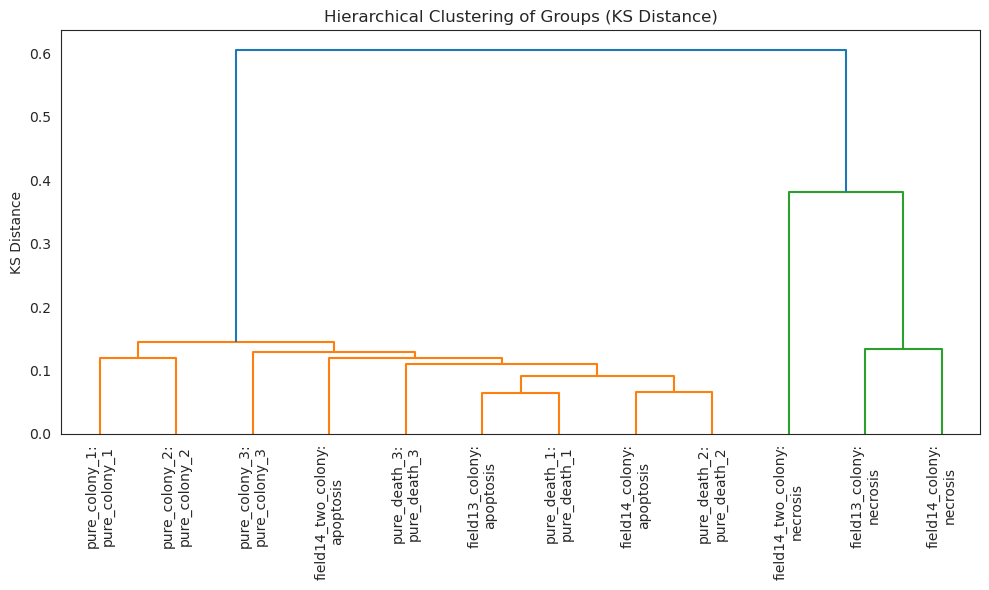

field13_colony:
apoptosis: Cluster 2
field13_colony:
necrosis: Cluster 3
field14_colony:
apoptosis: Cluster 2
field14_colony:
necrosis: Cluster 3
field14_two_colony:
apoptosis: Cluster 2
field14_two_colony:
necrosis: Cluster 4
pure_colony_3:
pure_colony_3: Cluster 2
pure_colony_1:
pure_colony_1: Cluster 1
pure_colony_2:
pure_colony_2: Cluster 1
pure_death_1:
pure_death_1: Cluster 2
pure_death_2:
pure_death_2: Cluster 2
pure_death_3:
pure_death_3: Cluster 2


In [23]:
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_ks_distance_matrix(filtered_df):
    group_names = filtered_df['GroupLabel'].unique()
    n = len(group_names)
    D_ks = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = filtered_df[filtered_df['GroupLabel'] == group_names[i]]['Difference'].values
            group_j_values = filtered_df[filtered_df['GroupLabel'] == group_names[j]]['Difference'].values
            stat, _ = ks_2samp(group_i_values, group_j_values)
            D_ks[i, j] = D_ks[j, i] = stat

    return D_ks, group_names

# Compute the KS distance matrix
ks_dist_matrix, group_names = compute_ks_distance_matrix(filtered_df)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(ks_dist_matrix), method='average')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (KS Distance)')
plt.ylabel('KS Distance')
plt.tight_layout()
plt.show()

# Assign clusters based on a threshold or number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Print the cluster assignments
for name, cluster in zip(group_names, clusters):
    print(f"{name}: Cluster {cluster}")


# Cluster on TOD from nucleuator- no noramlization

In [31]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
concatenated_data = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') and 'mix' not in file and "SKT" not in file and "out" not in file  and "ROI#2" not in file and "puredeath3" not in file:  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        # Read the CSV file
        df = pd.read_csv(file_path)
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,

            normalize=False,
            # n_type = 'onset_and_iqr',
            filter_neighbors_by_distance=True,
            filter_neighbors_by_level =True,
            neighbors_level=3,
            pure_type = 'necrosis'
        )
        from_nuc = de_qu.get_TOD_from_nucleator(level=3,)
        # Initialize a dictionary to store concatenated values


        # Concatenate values for all keys in from_nuc
        concatenated_data[file] = [value for key in from_nuc for value in from_nuc[key]]



/tmp/ipykernel_2566268/2939529455.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)


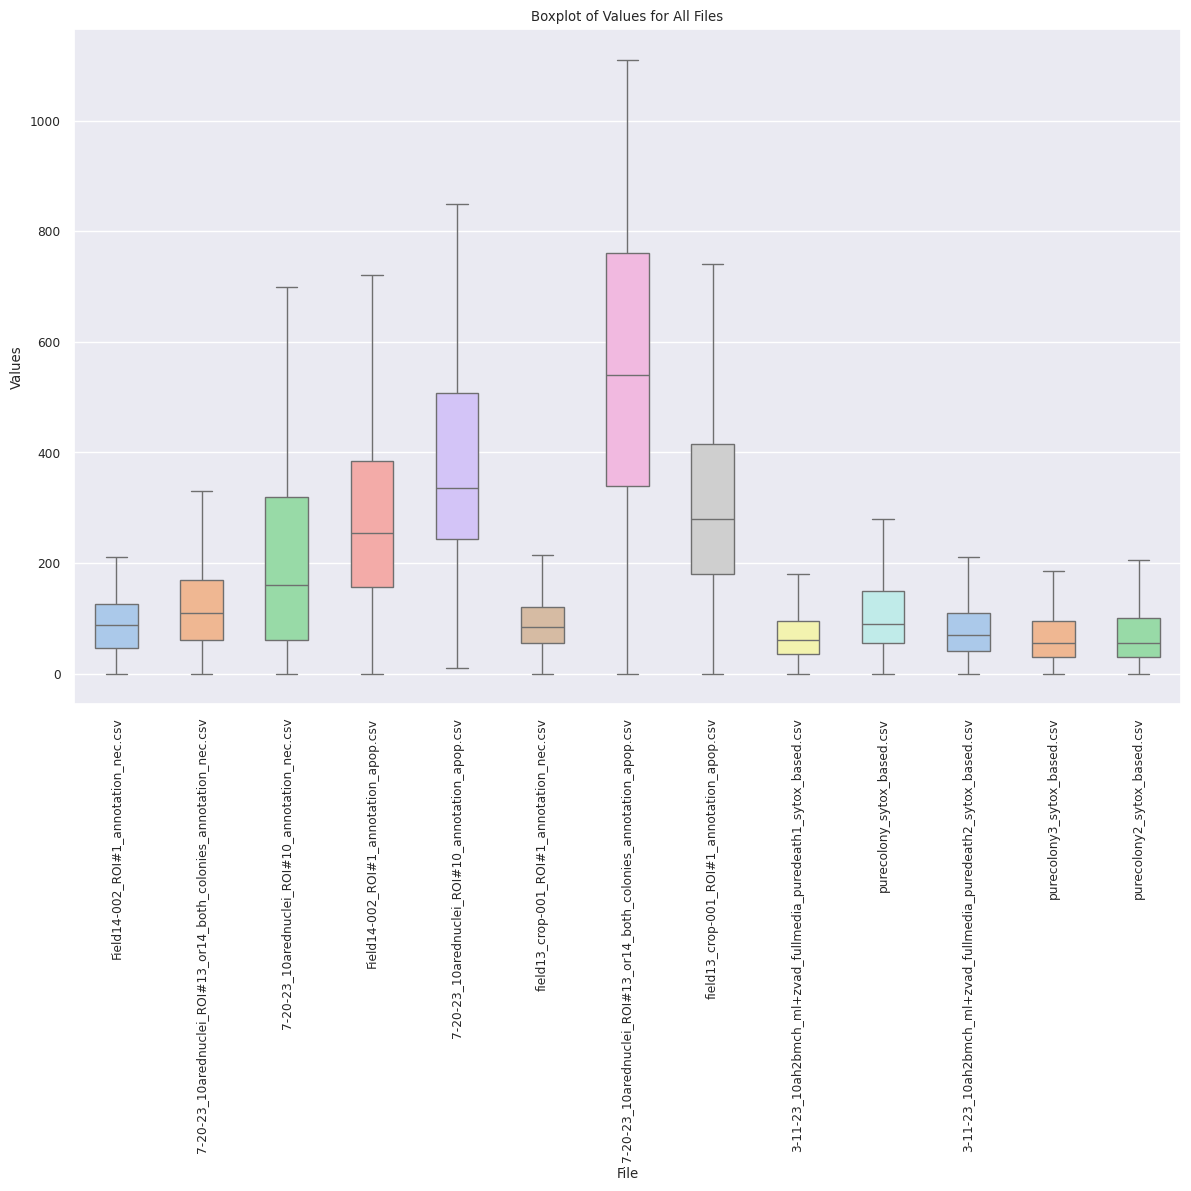

In [32]:
# Combine all data into a single DataFrame
all_data = []
for key, values in concatenated_data.items():
    all_data.extend([(key, value) for value in values])

df_combined = pd.DataFrame(all_data, columns=['File', 'Values'])

# Plot the boxplot
plt.figure(figsize=(12, 12))
sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)
plt.title('Boxplot of Values for All Files')
plt.xlabel('File')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## other distances: ks_2sample, energy_distance, wasserstein_distance:

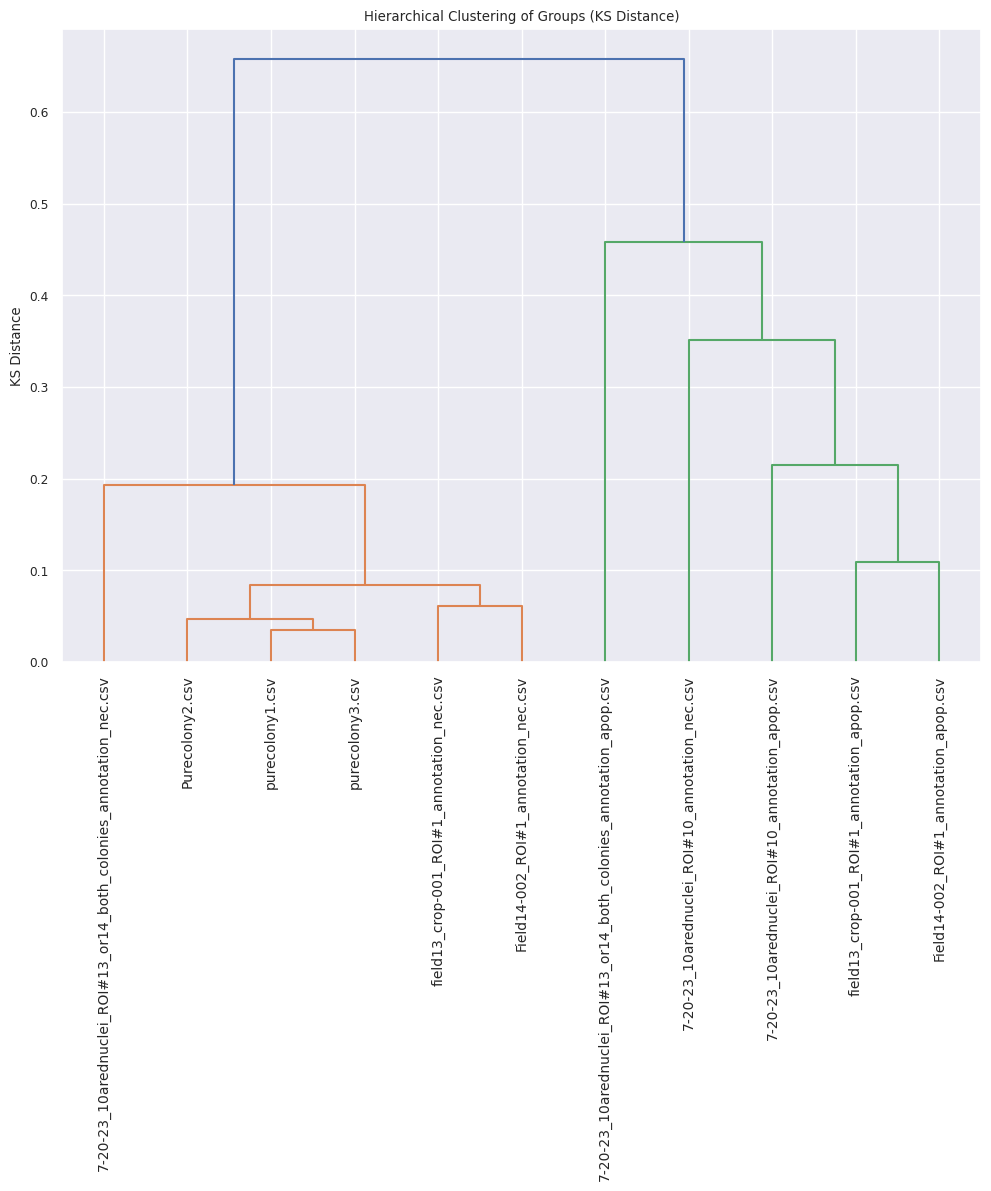

purecolony1.csv: Cluster 1
Purecolony2.csv: Cluster 1
purecolony3.csv: Cluster 1
7-20-23_10arednuclei_ROI#10_annotation_nec.csv: Cluster 3
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_apop.csv: Cluster 4
7-20-23_10arednuclei_ROI#10_annotation_apop.csv: Cluster 2
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv: Cluster 1
field13_crop-001_ROI#1_annotation_apop.csv: Cluster 2
field13_crop-001_ROI#1_annotation_nec.csv: Cluster 1
Field14-002_ROI#1_annotation_apop.csv: Cluster 2
Field14-002_ROI#1_annotation_nec.csv: Cluster 1


In [ ]:
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_ks_distance_matrix(df_combined):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_ks = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]]['Values'].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]]['Values'].values
            stat, _ = ks_2samp(group_i_values, group_j_values)
            D_ks[i, j] = D_ks[j, i] = stat

    return D_ks, group_names

# Compute the KS distance matrix
ks_dist_matrix, group_names = compute_ks_distance_matrix(df_combined)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(ks_dist_matrix), method='single')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (KS Distance)')
plt.ylabel('KS Distance')
plt.tight_layout()
plt.show()

# Assign clusters based on a threshold or number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Print the cluster assignments
for name, cluster in zip(group_names, clusters):
    print(f"{name}: Cluster {cluster}")


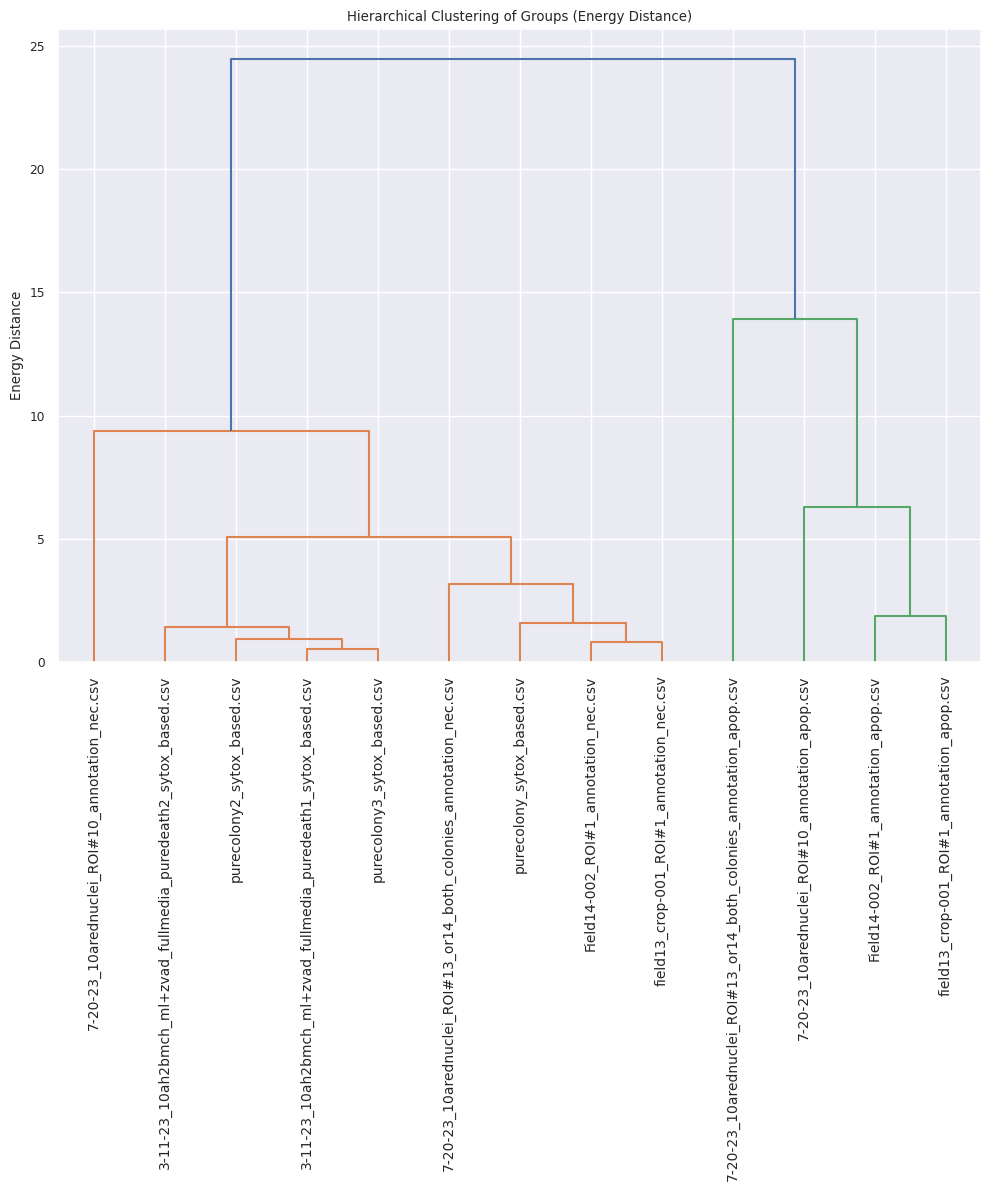

In [33]:
from scipy.stats import energy_distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_energy_distance_matrix(df_combined):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_energy = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]]['Values'].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]]['Values'].values
            dist = energy_distance(group_i_values, group_j_values)
            D_energy[i, j] = D_energy[j, i] = dist

    return D_energy, group_names

# Compute the energy distance matrix
energy_dist_matrix, group_names = compute_energy_distance_matrix(df_combined)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(energy_dist_matrix), method='complete')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (Energy Distance)')
plt.ylabel('Energy Distance')
plt.tight_layout()
plt.show()



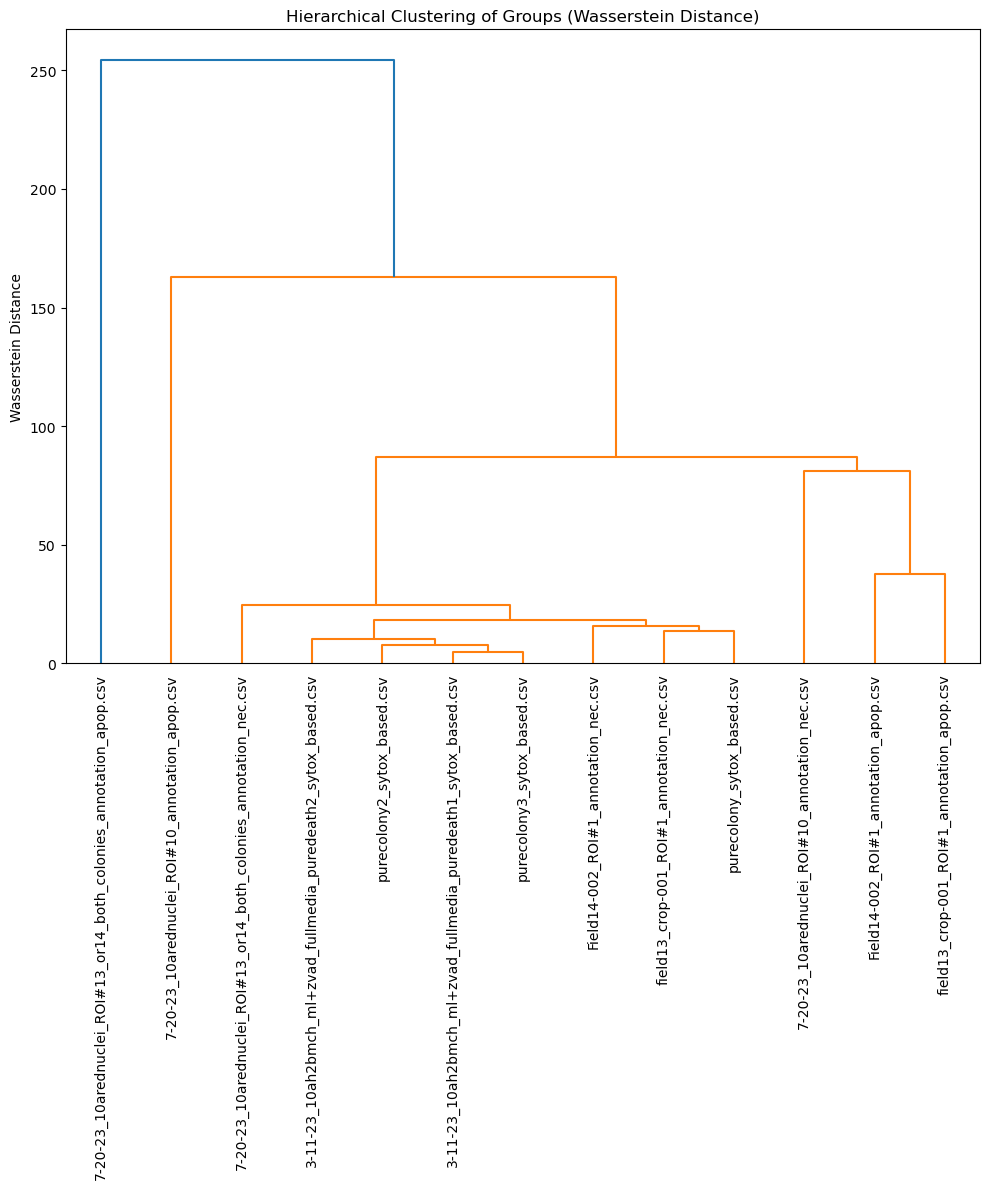

Field14-002_ROI#1_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#10_annotation_nec.csv: Cluster 2
Field14-002_ROI#1_annotation_apop.csv: Cluster 2
7-20-23_10arednuclei_ROI#10_annotation_apop.csv: Cluster 3
field13_crop-001_ROI#1_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_apop.csv: Cluster 4
field13_crop-001_ROI#1_annotation_apop.csv: Cluster 2
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv: Cluster 1
purecolony_sytox_based.csv: Cluster 1
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv: Cluster 1
purecolony3_sytox_based.csv: Cluster 1
purecolony2_sytox_based.csv: Cluster 1


In [14]:
from scipy.stats import wasserstein_distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_wasserstein_distance_matrix(df_combined):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_wasserstein = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]]['Values'].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]]['Values'].values
            dist = wasserstein_distance(group_i_values, group_j_values)
            D_wasserstein[i, j] = D_wasserstein[j, i] = dist

    return D_wasserstein, group_names

# Compute the Wasserstein distance matrix
wasserstein_dist_matrix, group_names = compute_wasserstein_distance_matrix(df_combined)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(wasserstein_dist_matrix), method='single')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (Wasserstein Distance)')
plt.ylabel('Wasserstein Distance')
plt.tight_layout()
plt.show()

# Assign clusters based on a threshold or number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Print the cluster assignments
for name, cluster in zip(group_names, clusters):
    print(f"{name}: Cluster {cluster}")


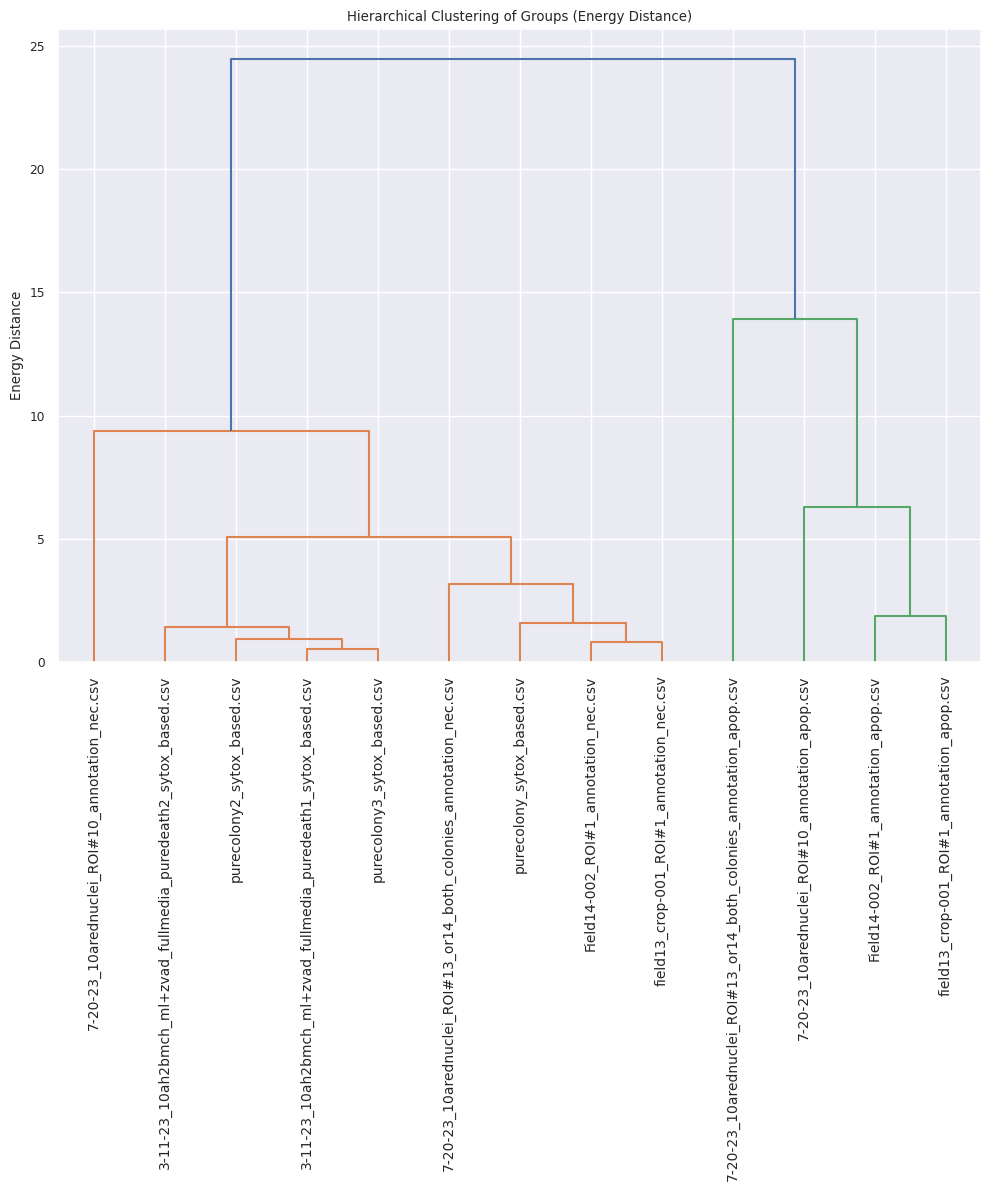

In [36]:
from scipy.stats import energy_distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_energy_distance_matrix(df_combined):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_energy = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]]['Values'].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]]['Values'].values
            dist = energy_distance(group_i_values, group_j_values)
            D_energy[i, j] = D_energy[j, i] = dist

    return D_energy, group_names

# Compute the energy distance matrix
energy_dist_matrix, group_names = compute_energy_distance_matrix(df_combined)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(energy_dist_matrix), method='complete')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (Energy Distance)')
plt.ylabel('Energy Distance')
plt.tight_layout()
plt.show()



group compare Field14-002_ROI#1_annotation_nec.csv , 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv, p-value: 2.1243471870485616e-06
group compare Field14-002_ROI#1_annotation_nec.csv , 7-20-23_10arednuclei_ROI#10_annotation_nec.csv, p-value: 9.73329652042902e-15
group compare Field14-002_ROI#1_annotation_nec.csv , Field14-002_ROI#1_annotation_apop.csv, p-value: 3.986825802947244e-62
group compare Field14-002_ROI#1_annotation_nec.csv , 7-20-23_10arednuclei_ROI#10_annotation_apop.csv, p-value: 1.0266260735661553e-24
group compare Field14-002_ROI#1_annotation_nec.csv , field13_crop-001_ROI#1_annotation_nec.csv, p-value: 0.6948526030829253
group compare Field14-002_ROI#1_annotation_nec.csv , 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_apop.csv, p-value: 1.5723149339304804e-83
group compare Field14-002_ROI#1_annotation_nec.csv , field13_crop-001_ROI#1_annotation_apop.csv, p-value: 2.821448062294166e-61
group compare Field14-002_ROI#1_annotation_nec.csv , 3-

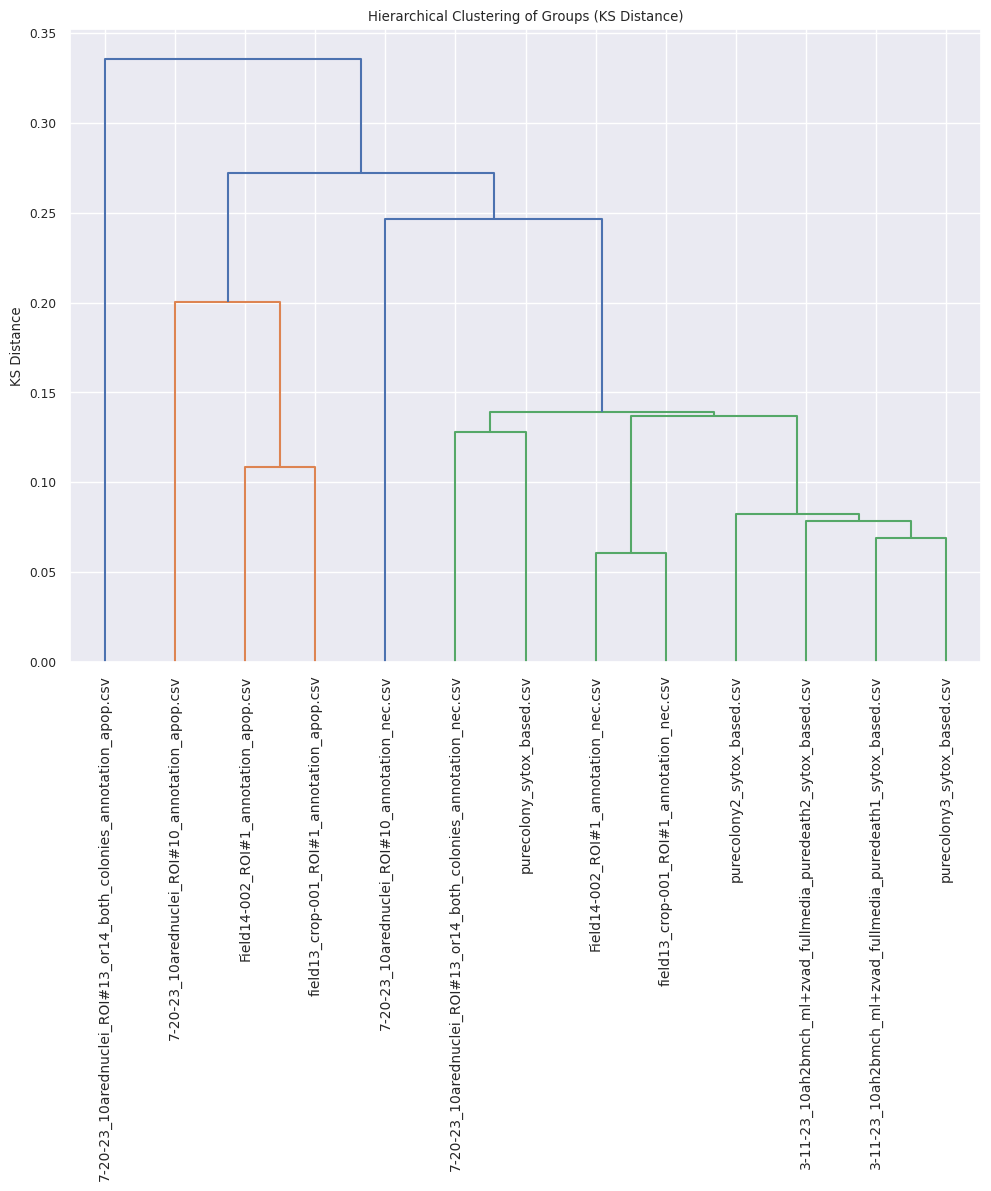

In [35]:
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_ks_distance_matrix(df_combined):
    group_names = df_combined['File'].unique()
    
    n = len(group_names)
    D_ks = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]]['Values'].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]]['Values'].values
            stat, val = ks_2samp(group_i_values, group_j_values)
            print(f"group compare {group_names[i]} , {group_names[j]}, p-value: {val}")
            D_ks[i, j] = D_ks[j, i] = stat

    return D_ks, group_names

# Compute the KS distance matrix
ks_dist_matrix, group_names = compute_ks_distance_matrix(df_combined)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(ks_dist_matrix), method='single')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (KS Distance)')
plt.ylabel('KS Distance')
plt.tight_layout()
plt.show()



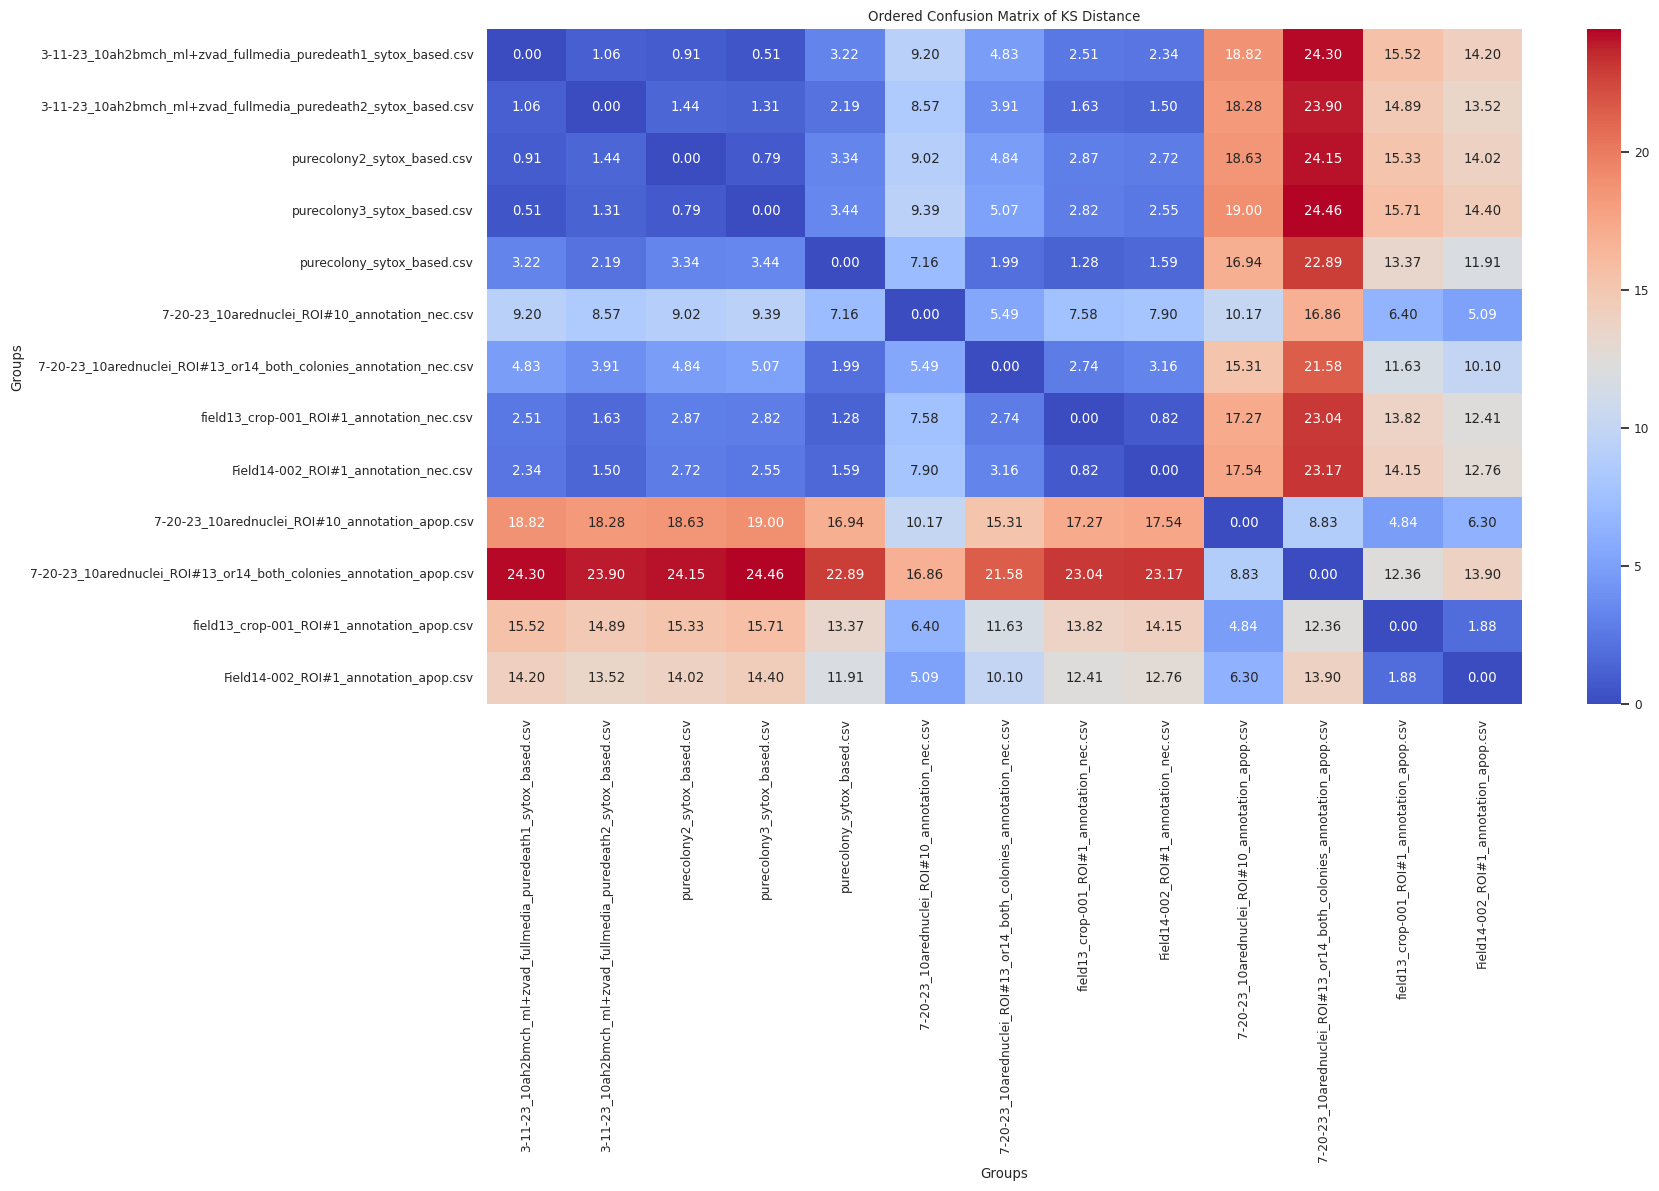

In [39]:

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert ks_dist_matrix to a DataFrame
ks_dist_df = pd.DataFrame(energy_dist_matrix, index=group_names, columns=group_names)

# Order the group names: "nec" first, then "apop"
ordered_group_names = sorted(group_names, key=lambda x: ("pure" not in x.lower(), "nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
ks_dist_df = ks_dist_df.loc[ordered_group_names, ordered_group_names]

# Plot the confusion matrix
plt.figure(figsize=(18,12))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)

# Format the plot
plt.title("Ordered Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

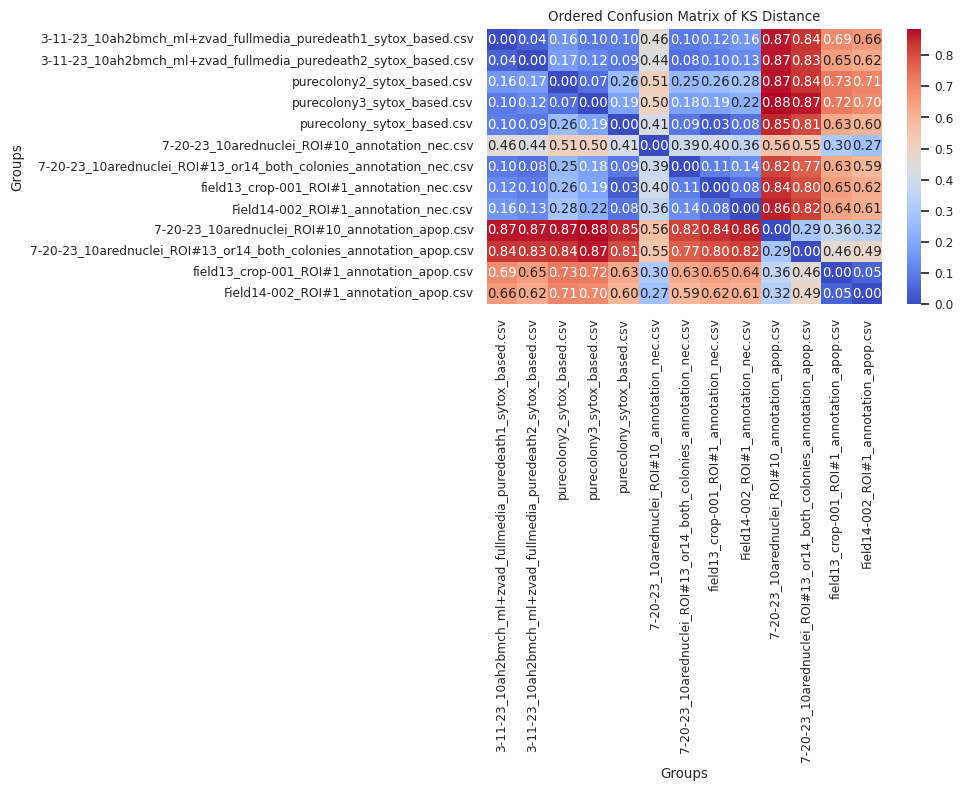

In [30]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert ks_dist_matrix to a DataFrame
ks_dist_df = pd.DataFrame(ks_dist_matrix, index=group_names, columns=group_names)

# Order the group names: "nec" first, then "apop"
ordered_group_names = sorted(group_names, key=lambda x: ("pure" not in x.lower(), "nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
ks_dist_df = ks_dist_df.loc[ordered_group_names, ordered_group_names]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)

# Format the plot
plt.title("Ordered Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

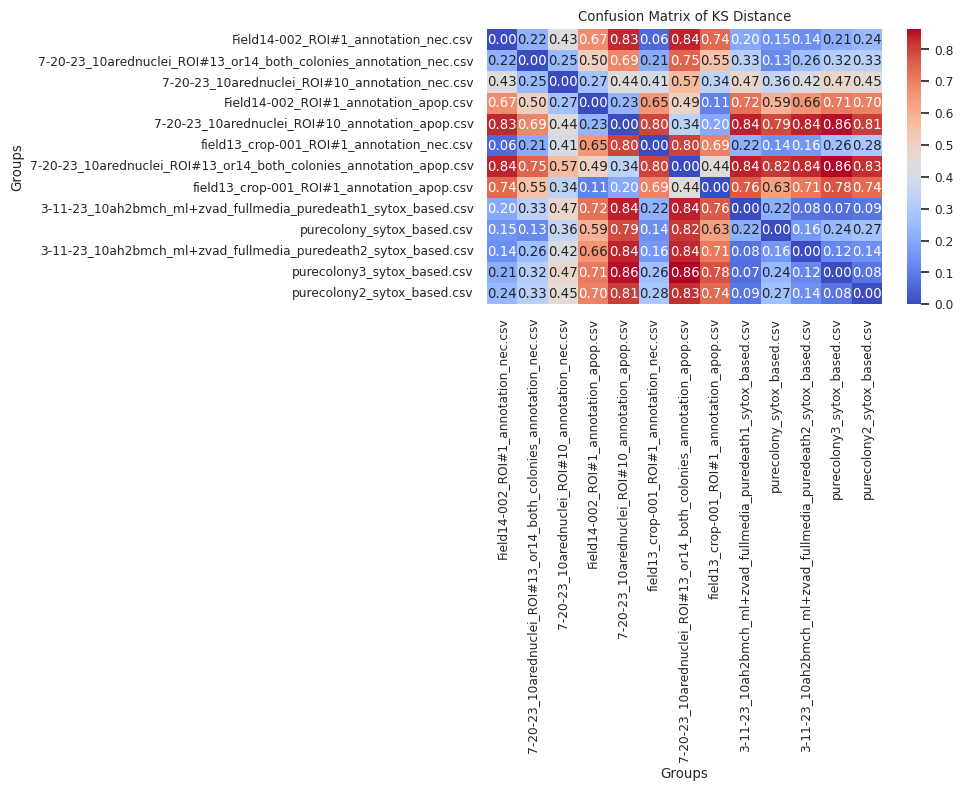

In [20]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=group_names, yticklabels=group_names)

# Format the plot
plt.title("Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()